# Simulation Based Inference to Remove Sampling Bias - inference for both variants jointly

Model  with parameters `beta`, `delta`, `mu_inf_SC`, `mu_inf_SA`, `mu_inf_AI`, `mu_inf_AC`, `mu_inf_AA`, `mu_susc_C`, `mu_susc_A`.

In [1]:
import os
import pickle
from functools import partial
from itertools import product
from time import perf_counter

import bayesflow as bf
import numpy as np
import pandas as pd
import tensorflow as tf
from bayesflow import default_settings as defaults
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.helper_networks import MultiConv1D
from bayesflow.networks import InvertibleNetwork
from bayesflow.simulation import GenerativeModel, Prior, Simulator, ContextGenerator
from bayesflow.trainers import Trainer
from matplotlib import pyplot as plt
from matplotlib.cm import viridis
from matplotlib.patches import Patch
from tarp import get_tarp_coverage
from tensorflow.keras.layers import Dense, LSTM, GRU, Bidirectional
from tensorflow.keras.models import Sequential
from tqdm import tqdm

from helper_functions import normalize_household_data
from parameter_cis import sampling_parameter_cis

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
job_array_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0))
n_procs = int(os.environ.get('SLURM_CPUS_PER_TASK', 1))

In [3]:
train_network = False
presimulate = False
batch_size = 128
iterations_per_epoch = 1000
# 10000 batches to be generated, 10 epoch until batches are used up
max_epochs = 250  # 100

## Define model and prior

In [4]:
# we assume that besides alpha, if parameters are fixed for one variant, they are fixed for the other variant as well
fixed_parameters = {
    'alpha': {
        "alpha": 0.001,  # baseline infection rate
        #"delta": 1.3,
        "mu_protect_acq": 0.8,  # not enough data to estimate
        "mu_protect_transm": 1.  # not enough data to estimate
    },
    'omicron': {
        #"alpha": 0.002,  # introduces too much variation in the data
        #"delta": 1.4,
        "mu_protect_acq": 0.8,  # not enough data to estimate
        "mu_protect_transm": 0.8  # not enough data to estimate
    }
}
param_names_raw = ['alpha', 'beta', 'delta',
                   'mu_inf_SC', 'mu_inf_SA', 'mu_inf_AI', 'mu_inf_AC', 'mu_inf_AA',
                   'mu_susc_C', 'mu_susc_A',
                   'mu_protect_acq', 'mu_protect_transm']
# Drop param names that are in fixed_parameters['alpha']
param_names_a = ['alpha_' + param for param in param_names_raw if param not in fixed_parameters['alpha']]
param_names_o = ['omicron_' + param for param in param_names_raw if param not in fixed_parameters['omicron']]
param_names = param_names_a + param_names_o

mu_count_a = len([param for param in param_names if param.startswith('alpha_mu')])
mu_count_o = len([param for param in param_names if param.startswith('omicron_mu')])
n_params = len(param_names)

In [5]:
# define the prior    
def prior(batch_size: int) -> np.ndarray:
    param_batch = np.zeros((batch_size, n_params))
    
    # alpha wave
    # alpha
    # param_batch[:, 0] = np.random.uniform(0, 0.1, batch_size)
    # log(beta)
    param_batch[:, 0] = np.random.normal(0, 1, batch_size)
    # delta
    if 'alpha_delta' in param_names:
        param_batch[:, 1] = np.random.normal(0, 1, batch_size)
        #param_batch[:, 1] = np.random.uniform(-3, 3, batch_size)
    # log(mu_...)
    param_batch[:, (len(param_names_a)-mu_count_a):len(param_names_a)] = np.random.normal(0, 1, (batch_size, mu_count_a))
    
    # omicron wave
    # alpha
    param_batch[:, 0+len(param_names_a)] = np.random.uniform(fixed_parameters['alpha']['alpha'], 0.1, batch_size)
    # log(beta)
    param_batch[:, 1+len(param_names_a)] = np.random.normal(0, 1, batch_size)
    # delta
    if 'omicron_delta' in param_names:
        param_batch[:, 2+len(param_names_a)] = np.random.normal(0, 1, batch_size)
        #param_batch[:, 1] = np.random.uniform(-3, 3, batch_size)
    # log(mu_...)
    param_batch[:, (len(param_names)-mu_count_o):] = np.random.normal(0, 1, (batch_size, mu_count_o))
    return param_batch

In [6]:
def make_prior_relative(params: np.ndarray) -> np.ndarray:
    params = params.copy()
    # reparameterize, such that omicron parameters are relative to alpha parameters
    for pi, par_name in enumerate(param_names[len(param_names_a):], start=len(param_names_a)):
        # find the corresponding alpha parameter
        alpha_p_name = par_name[len('omicron_'):]
        if alpha_p_name in fixed_parameters['alpha']:
            params[:, pi] = params[:, pi] - fixed_parameters['alpha'][alpha_p_name]
        else:
            params[:, pi] = params[:, pi] - params[:, param_names_a.index('alpha_' + alpha_p_name)]
    return params

def make_prior_absolute(params: np.ndarray) -> np.ndarray:
    params = params.copy()
    # reparameterize, such that omicron parameters are not relative to alpha parameters anymore
    for pi, par_name in enumerate(param_names[len(param_names_a):], start=len(param_names_a)):
        # find the corresponding alpha parameter
        alpha_p_name = par_name[len('omicron_'):]
        if alpha_p_name in fixed_parameters['alpha']:
            if params.ndim == 2:
                params[:, pi] = params[:, pi] + fixed_parameters['alpha'][alpha_p_name]
            else:
                params[:, :, pi] = params[:, :, pi] + fixed_parameters['alpha'][alpha_p_name]
        else:
            if params.ndim == 2:
                params[:, pi] = params[:, pi] + params[:, param_names_a.index('alpha_' + alpha_p_name)]
            else:
                params[:, :, pi] = params[:, :, pi] + params[:, :, param_names_a.index('alpha_' + alpha_p_name)]
    return params

In [7]:
np.random.seed(42)
_prior_draws = prior(1000)
_prior_draws = make_prior_relative(_prior_draws)

# for normalization of the parameters
prior_mean = np.mean(_prior_draws, axis=0)
prior_std = np.std(_prior_draws, axis=0)

assert prior_mean.size == prior_std.size, 'Number of parameters do not match'
assert prior_mean.size == prior(1).shape[1], \
    'Number of parameters do not match in prior'

In [8]:
# check if GPU is available
n_gpus = len(tf.config.experimental.list_physical_devices('GPU'))
print("Num GPUs Available: ", n_gpus)

if n_gpus > 0:
    def simulator_both_variants(log_params: np.ndarray,
                                selection_procedure: str,
                                minimal_length: int,
                                fixed_parameters_dict: dict = None)  -> np.ndarray:
        # gpu cannot handle R modules for some reason
        raise NotImplementedError('simulator function not implemented')
else:
    from Simulator.simulator import simulator_both_variants

# if name starts with mu, create log name
log_param_names = []
for p_name in param_names:
    if p_name == 'alpha_delta' or p_name == 'omicron_delta' or p_name == 'alpha_alpha' or p_name == 'omicron_alpha':
        log_param_names.append(p_name)
    else:
        log_param_names.append(f'log({p_name})')
    
assert n_params == prior_mean.size, 'Number of parameters in normalization do not match names'
print(f"Number of parameters: {n_params}")

Num GPUs Available:  0


Attaching package: ‘dplyr’



    filter, lag



    intersect, setdiff, setequal, union


Attaching package: ‘actuar’



    sd, var



    cm




Number of parameters: 19


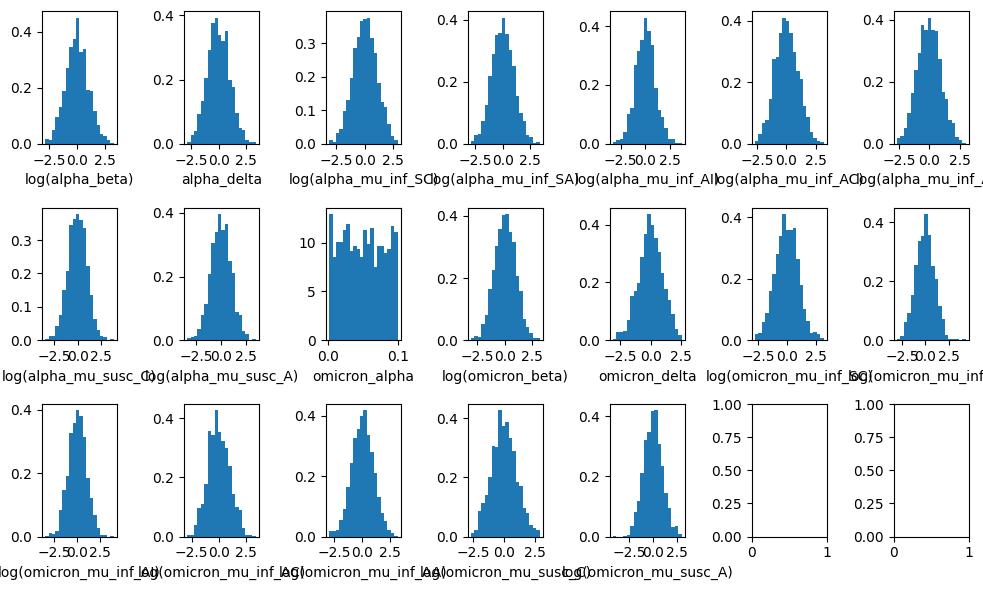

In [9]:
# plot prior
fix, ax = plt.subplots(3, len(log_param_names) // 3+1, figsize=(10, 6), sharey=False, tight_layout=True)
ax = ax.flatten()
n_samples = 1000
prior_samples = prior(n_samples)
prior_samples = make_prior_relative(prior_samples)
prior_samples = make_prior_absolute(prior_samples)
for i in range(len(log_param_names)):
    ax[i].hist(prior_samples[:, i], bins=20, density=True)
    ax[i].set_xlabel(log_param_names[i])
plt.show()

## Define the generative model for BayesFlow

In [10]:
bayesflow_prior = Prior(
    batch_prior_fun=prior,
    param_names=log_param_names
)
gen = ContextGenerator(
    batchable_context_fun=lambda : np.random.choice(['pedcov', 'random']),
)
bayes_simulator = Simulator(
    simulator_fun=partial(simulator_both_variants, fixed_parameters_dict=fixed_parameters),
    context_generator=gen
)
generative_model = GenerativeModel(
    prior=bayesflow_prior, 
    simulator=bayes_simulator,
    skip_test=True
)

## Generate training data

In [11]:
presim_folder = 'presimulations_joint_variants'

if presimulate:    
    np.random.seed(42)
    print('presimulating')
    start_time = perf_counter()
    from time import sleep
    sleep(job_array_id)

    for job_1000 in range(10):
        add_to_id = job_1000 * 1000
        # we create on batch per job and save it in a folder
        epoch_id = (job_array_id+add_to_id) // iterations_per_epoch
        print(f'presimulating epoch {epoch_id} job {job_array_id+add_to_id}')
        os.makedirs(presim_folder, exist_ok=True)
        generative_model.presimulate_and_save(batch_size=batch_size, 
                                              folder_path=f'{presim_folder}/epoch_{epoch_id}',
                                              iterations_per_epoch=1,
                                              epochs=1,
                                              extend_from=job_array_id+add_to_id,
                                              disable_user_input=True)
    end_time = perf_counter()
    print(f'simulation time: {(end_time-start_time)/60} minutes')
    #exit()

In [12]:
# generate validation data
sim_folder = 'sim_data_joint'
valid_file_name = "valid_data_both_variants"

np.random.seed(42)
n_valid = 128
prior_draws = bayesflow_prior(n_valid // 2)
valid_data_dict = {}

for selection in ['pedcov', 'random']:
    
    valid_file_name_vs = f"{valid_file_name}_{selection}"
    if os.path.exists(f'{sim_folder}/{valid_file_name_vs}.pickle'):
        with open(f'{sim_folder}/{valid_file_name_vs}.pickle', 'rb') as f:
            valid_data_dict[f'{selection}'] = pickle.load(f)
    else:
        print(f"Simulating validation data with {selection}")
        new_valid_data = {
            'prior_draws': prior_draws['prior_draws'].copy(),
            'sim_batchable_context': np.array([[selection] for _ in range(n_valid // 2)]),
        }
        new_valid_data['sim_data'] = np.array([simulator_both_variants(params,
                                                         selection_procedure=selection,
                                                         fixed_parameters_dict=fixed_parameters)
                                               for params in new_valid_data['prior_draws']])
        # save the data
        with open(f'{sim_folder}/{valid_file_name_vs}.pickle', 'wb') as f:
            pickle.dump(new_valid_data, f)
        valid_data_dict[f'{selection}'] = new_valid_data

# we cannot use both variants at the same time for validation since not batchable
valid_data = {key: np.concatenate((valid_data_dict['pedcov'][key],
                                   valid_data_dict['random'][key])
                                  ) for key in valid_data_dict['pedcov'].keys()}

In [13]:
def configurator(forward_dict: dict, not_inform_selection: bool = False, drop_random: bool = False) -> dict:
    out_dict = {}

    # Extract data (already normalized)
    x = forward_dict["sim_data"]
    out_dict['summary_conditions'] = x.astype(np.float32)
    
    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        params = make_prior_relative(params)
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
        
    # non batchable context can come as a list or as a single value
    sim_batchable_context = np.array(forward_dict['sim_batchable_context']).flatten()
        
    # Extract context
    selection_cond = np.array(
            [[0. if s == 'pedcov' else 1.] 
             for s in sim_batchable_context]
        )
    
    if drop_random:
        print('Warning: Dropping random selection')
        not_inform_selection = True
        # Extract context
        keep_indices = np.array([True if s == 'pedcov' else False for s in sim_batchable_context])
        if keep_indices.size == 0:
            # If keep_indices is empty, select a random index to not have an empty batch
            print("keep_indices is empty, select a random index")
            keep_indices = np.array([np.random.choice(len(sim_batchable_context))])
        
        selection_cond = selection_cond[keep_indices]
        out_dict['summary_conditions'] = out_dict['summary_conditions'][keep_indices]
        if 'parameters' in out_dict.keys():
            out_dict['parameters'] = out_dict['parameters'][keep_indices]
            
    if not_inform_selection:
        # drop direct condition on selection procedure
        print('Warning: Not informing about selection procedure')
    else:
        out_dict['direct_condition'] = selection_cond.astype(np.float32)
    
    if 'parameters' in out_dict.keys():
        assert out_dict['summary_conditions'].shape[0] == out_dict['parameters'].shape[0], \
            'Number of samples in summary conditions and parameters do not match'
    return out_dict

In [14]:
def renormalize_params(params: np.ndarray, keep_transform: bool = False) -> np.ndarray:
    un_scaled_params = params.copy()
    un_scaled_params = un_scaled_params * prior_std + prior_mean
    
    if not keep_transform:
        un_scaled_params = make_prior_absolute(un_scaled_params)
        
        for p_i in range(n_params):
            if log_param_names[p_i][:3] != 'log':
                continue
                
            if un_scaled_params.ndim == 2:
                un_scaled_params[:, p_i] = np.exp(un_scaled_params[:, p_i])
            elif un_scaled_params.ndim == 3:
                 un_scaled_params[:, :, p_i] = np.exp(un_scaled_params[:, :, p_i])
            else:
                raise ValueError('Invalid number of dimensions')
    return un_scaled_params

## Define the neural network architectures

In [15]:
# define the network    
class GroupSummaryNetwork(tf.keras.Model):
    """Network to summarize the data of groups of cells.  Each group is passed through a series of convolutional layers
    followed by an LSTM layer. The output of the LSTM layer is then pooled across the groups and dense layer applied
    to obtain a summary of fixed dimensionality. The network is invariant to the order of the groups.
    """
    def __init__(
            self,
            summary_dim,
            num_conv_layers=2,
            rnn_units=128,
            bidirectional=True,
            conv_settings=None,
            use_attention=False,
            return_attention_weights=False,
            use_GRU=True,
            **kwargs
    ):
        super().__init__(**kwargs)

        if conv_settings is None:
            conv_settings = defaults.DEFAULT_SETTING_MULTI_CONV

        conv = Sequential([MultiConv1D(conv_settings) for _ in range(num_conv_layers)])
        self.group_conv = tf.keras.layers.TimeDistributed(conv)
        self.use_attention = use_attention
        self.return_attention_weights = return_attention_weights
        self.pooling = tf.keras.layers.GlobalAveragePooling1D()
        
        if self.use_attention:
            self.attention = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=rnn_units)
        
        if use_GRU:
            rnn = Bidirectional(GRU(rnn_units, return_sequences=use_attention)) if bidirectional else GRU(rnn_units, return_sequences=use_attention)
        else:
            rnn = Bidirectional(LSTM(rnn_units, return_sequences=use_attention)) if bidirectional else LSTM(rnn_units, return_sequences=use_attention)   
        self.group_rnn = tf.keras.layers.TimeDistributed(rnn)
            
        self.out_layer = Dense(summary_dim, activation="linear")
        self.summary_dim = summary_dim

    def call(self, x, **kwargs):
        """Performs a forward pass through the network by first passing `x` through the same rnn network for
        each household and then pooling the outputs across households.

        Parameters
        ----------
        x : tf.Tensor
            Input of shape (batch_size, n_groups, n_time_steps, n_features)

        Returns
        -------
        out : tf.Tensor
            Output of shape (batch_size, summary_dim)
        """
        # Apply the RNN to each group
        out = self.group_conv(x, **kwargs) 
        out = self.group_rnn(out, **kwargs)  # (batch_size, n_groups, lstm_units)
        # if attention is used, return full sequence (batch_size, n_groups, n_time_steps, lstm_units)
        # bidirectional LSTM returns 2*lstm_units

        if self.use_attention:
            # learn a query vector to attend over the time points
            query = tf.reduce_mean(out, axis=1)
            # Reshape query to match the required shape for attention
            query = tf.expand_dims(query, axis=1)  # (batch_size, 1, n_time_steps, lstm_units)
            if not self.return_attention_weights:
                out = self.attention(query, out, **kwargs)  # (batch_size, 1, n_time_steps, lstm_units)
            else:
                out, attention_weights = self.attention(query, out, return_attention_scores=True, **kwargs)
                attention_weights = tf.squeeze(attention_weights, axis=2)
            out = tf.squeeze(out, axis=1)  # Remove the extra dimension (batch_size, n_time_steps, lstm_units)
            out = self.pooling(out, **kwargs)  # (batch_size, 1, lstm_units)
        else:
            # pooling over groups, this totally invariants to the order of the groups
            out = self.pooling(out, **kwargs)  # (batch_size, lstm_units)
        # apply dense layer
        out = self.out_layer(out, **kwargs)  # (batch_size, summary_dim)
        
        if self.return_attention_weights:
            return out, attention_weights
        return out

In [16]:
# settings
net_id = 5  # 5 for both selection methods, 6 for only PedCov

coupling_settings_spline = {
    "num_dense": 3,
    "dense_args": dict(
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    "dropout_prob": 0.2,
    "bins": 16,
}
summary_loss = 'MMD'
drop_random_selection = False

if net_id == 0:
    amortizer_name = 'amortizer-sampling-bias-both_variants-6'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 6
    use_attention = False
elif net_id == 1:
    amortizer_name = 'amortizer-sampling-bias-both_variants-6-attention'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 6
    use_attention = True
elif net_id == 2:
    amortizer_name = 'amortizer-sampling-bias-both_variants-7'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 7
    use_attention = False
elif net_id == 3:
    amortizer_name = 'amortizer-sampling-bias-both_variants-7-attention'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 7
    use_attention = True
elif net_id == 4:
    amortizer_name = 'amortizer-sampling-bias-both_variants-8'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 8
    use_attention = False
elif net_id == 5:
    amortizer_name = 'amortizer-sampling-bias-both_variants-8-attention'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 8
    use_attention = True
elif net_id == 6:
    amortizer_name = 'amortizer-sampling-bias-both_variants-6-attention-pedcov-only'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 7
    use_attention = True
    drop_random_selection = True
elif net_id == 7:
    amortizer_name = 'amortizer-sampling-bias-both_variants-7-attention-pedcov-only'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 8
    use_attention = True
    drop_random_selection = True
elif net_id == 8:
    amortizer_name = 'amortizer-sampling-bias-both_variants-8-attention-pedcov-only'
    coupling_settings = coupling_settings_spline
    num_coupling_layers = 8
    use_attention = True
    drop_random_selection = True
else:
    raise ValueError('Invalid network id')

In [17]:
summary_net = GroupSummaryNetwork(
    summary_dim=n_params*2,
    rnn_units=32,  # multiple of 32 hidden units
    use_attention=use_attention,
    return_attention_weights=False,  # only needed for diagnostics of attention
)

inference_net = InvertibleNetwork(
    num_params=n_params,
    num_coupling_layers=num_coupling_layers,
    coupling_design='spline',
    coupling_settings=coupling_settings,
    permutation="learnable"
)

In [18]:
amortizer = AmortizedPosterior(
    inference_net=inference_net, 
    summary_net=summary_net,
    summary_loss_fun=summary_loss
)

amortizer_folder = 'amortizer_joint'
checkpoint_path = amortizer_folder + '/' + amortizer_name
os.makedirs(amortizer_folder, exist_ok=True)
print(checkpoint_path)

# build the trainer with networks and generative model
max_to_keep = 7
trainer = Trainer(
    amortizer=amortizer,
    # during training, we drop random selection if we want to train on PedCov only
    # during inference, we are not dropping random selection, but we do not inform the network about the selection procedure
    configurator=partial(configurator, drop_random=drop_random_selection) if train_network else 
        partial(configurator, not_inform_selection=drop_random_selection),   
    generative_model=generative_model,
    checkpoint_path=checkpoint_path,
    skip_checks=True,
    max_to_keep=max_to_keep
)

amortizer_joint/amortizer-sampling-bias-both_variants-8-attention


INFO:root:Loaded loss history from amortizer_joint/amortizer-sampling-bias-both_variants-8-attention/history_203.pkl.
INFO:root:Networks loaded from amortizer_joint/amortizer-sampling-bias-both_variants-8-attention/ckpt-203


In [19]:
def custom_loader(file_path):
    """Uses pickle to load, but each path is folder with multiple files, each one batch"""
    # load all files in folder
    loaded_presimulations = []
    for file in os.listdir(file_path):
        with open(os.path.join(file_path, file), 'rb') as batch_file:
            batch = pickle.load(batch_file)[0]
            assert isinstance(batch, dict)  # only one batch per file
            loaded_presimulations.append(batch)
    # shuffle list, so iterations are random, only batches stay the same
    np.random.shuffle(loaded_presimulations)
    return loaded_presimulations

## Train the network

In [20]:
if train_network:
    # simulation done before, start training now
    trainer._setup_optimizer(
        optimizer=None,
        epochs=max_epochs,
        iterations_per_epoch=iterations_per_epoch
    )
    optimizer = trainer.optimizer

    start_time = perf_counter()
    history = trainer.train_from_presimulation(
        presimulation_path=presim_folder,
        optimizer=optimizer,
        max_epochs=max_epochs,
        early_stopping=True,
        custom_loader=custom_loader,
        validation_sims=valid_data
    )

    end_time = perf_counter()
    print(f'training time: {(end_time-start_time)/60} minutes')
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

In [21]:
# Check if training converged
if np.isnan(history['val_losses'].iloc[-1]).any():
    print('Training failed with NaN loss at the end')
    if np.isnan(history['val_losses'].iloc[-max_to_keep:]).all():
        print('Training failed with NaN loss for all latest checkpoints')

# Find the checkpoint with the lowest validation loss out of the last 7
recent_losses = history['val_losses'].iloc[-max_to_keep:]
best_valid_epoch = recent_losses['Loss'].idxmin() + 1  # checkpoints are 1-based indexed
new_checkpoint = trainer.manager.latest_checkpoint.rsplit('-', 1)[0] + f'-{best_valid_epoch}'    
trainer.checkpoint.restore(new_checkpoint)
print("Networks loaded from {}".format(new_checkpoint))
print(f"Best validation loss: {recent_losses['Loss'].min()}")

Networks loaded from amortizer_joint/amortizer-sampling-bias-both_variants-8-attention/ckpt-197
Best validation loss: 8.089227676391602


## Check the training convergence

In [22]:
results_folder = 'results_joint_variants'
os.makedirs(results_folder, exist_ok=True)

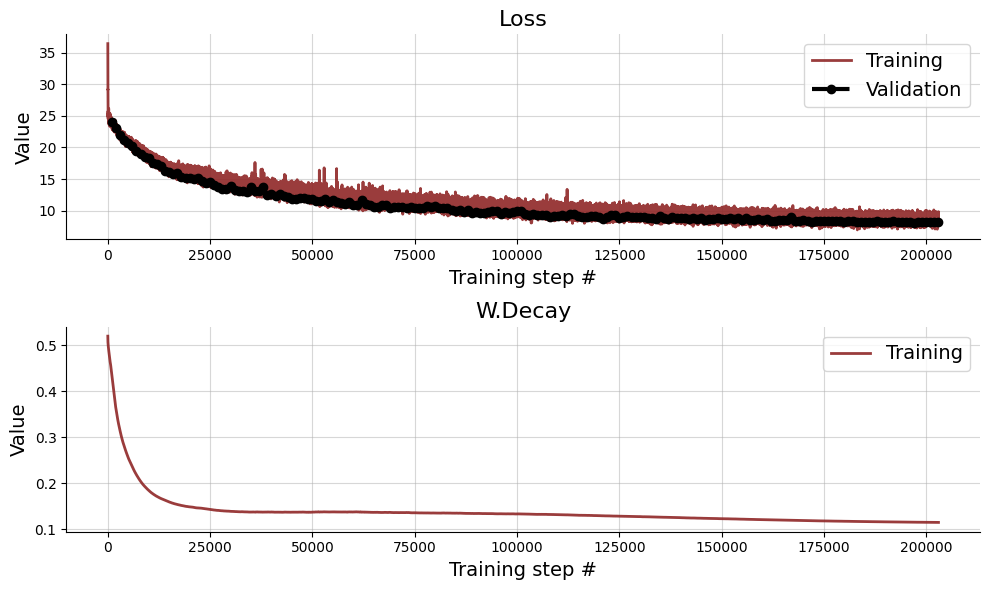

In [23]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [24]:
test_sims = trainer.configurator(valid_data)

In [25]:
# we need to join samples from both variants to check SBC and other diagnostics
posterior_samples = amortizer.sample(test_sims, n_samples=100)
posterior_samples = renormalize_params(posterior_samples, keep_transform=True)

prior_draws = renormalize_params(test_sims["parameters"], keep_transform=True)

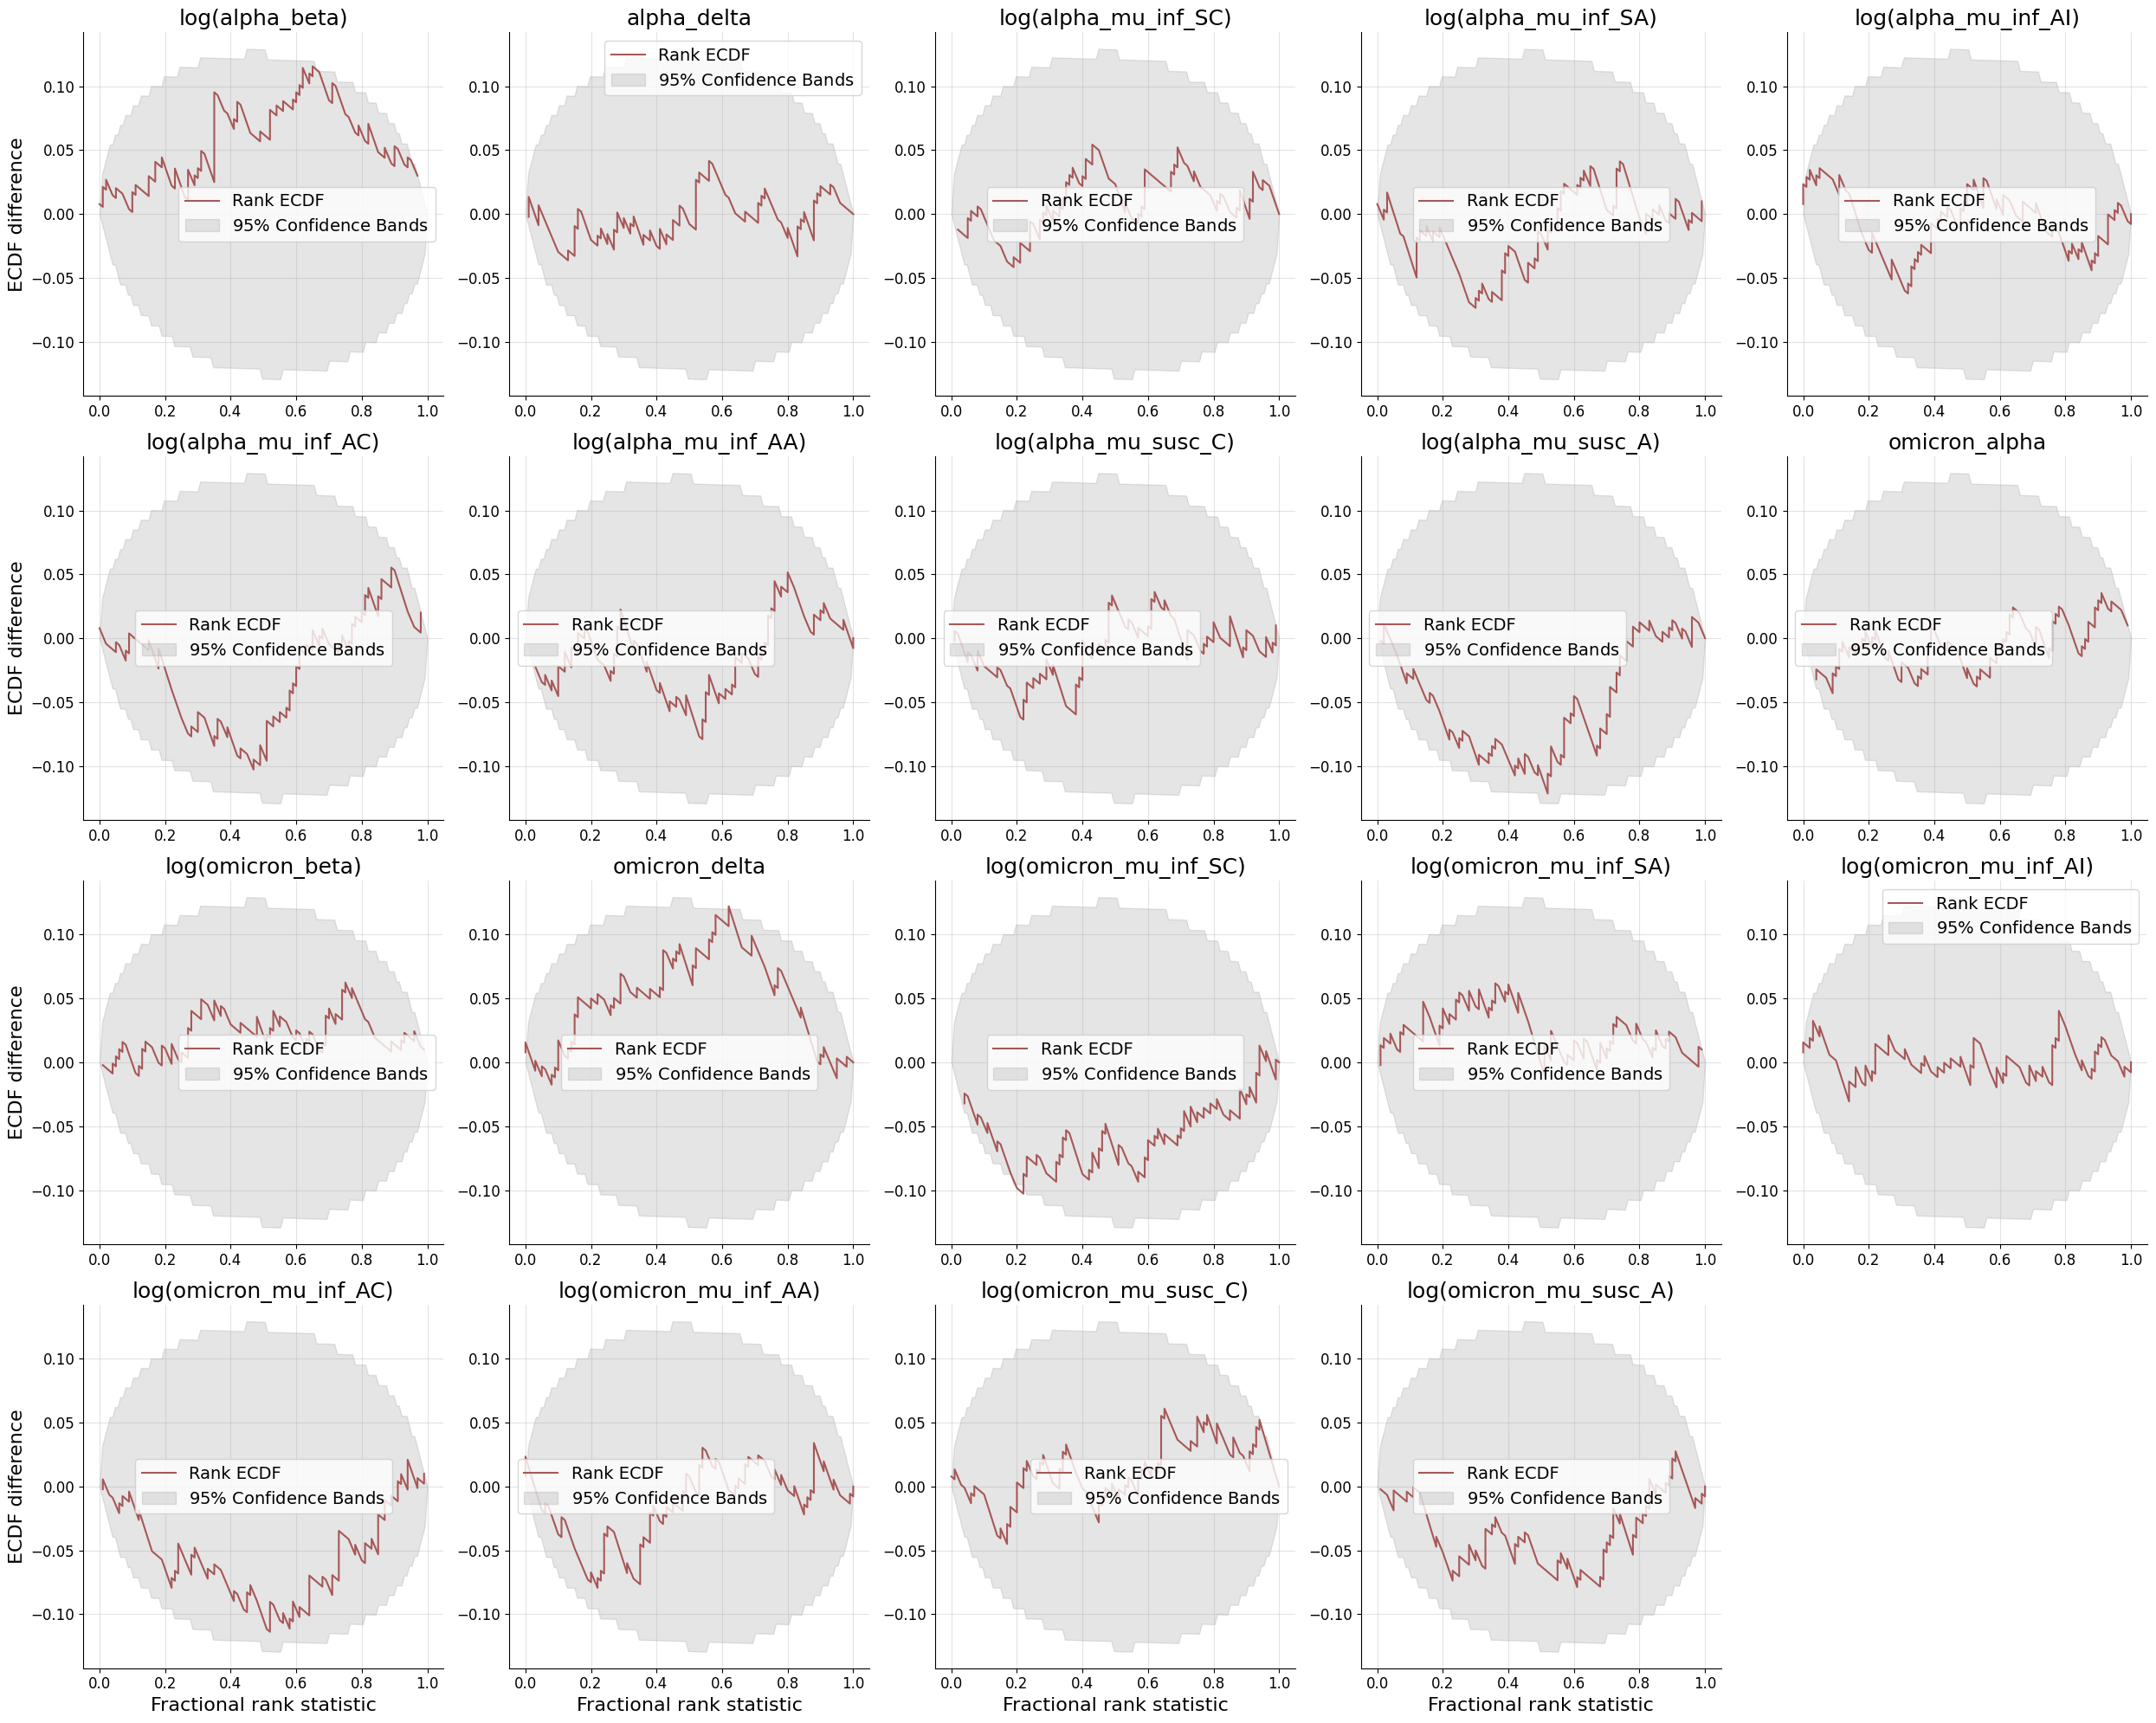

In [26]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=log_param_names)
fig.savefig(f'{results_folder}/{amortizer_name}_sbc.png')

In [27]:
# remove nan
remove = np.any(np.isnan(posterior_samples), axis=(1, 2))
if np.any(remove):
    print(f"Removing {np.sum(remove)} entries with nan")

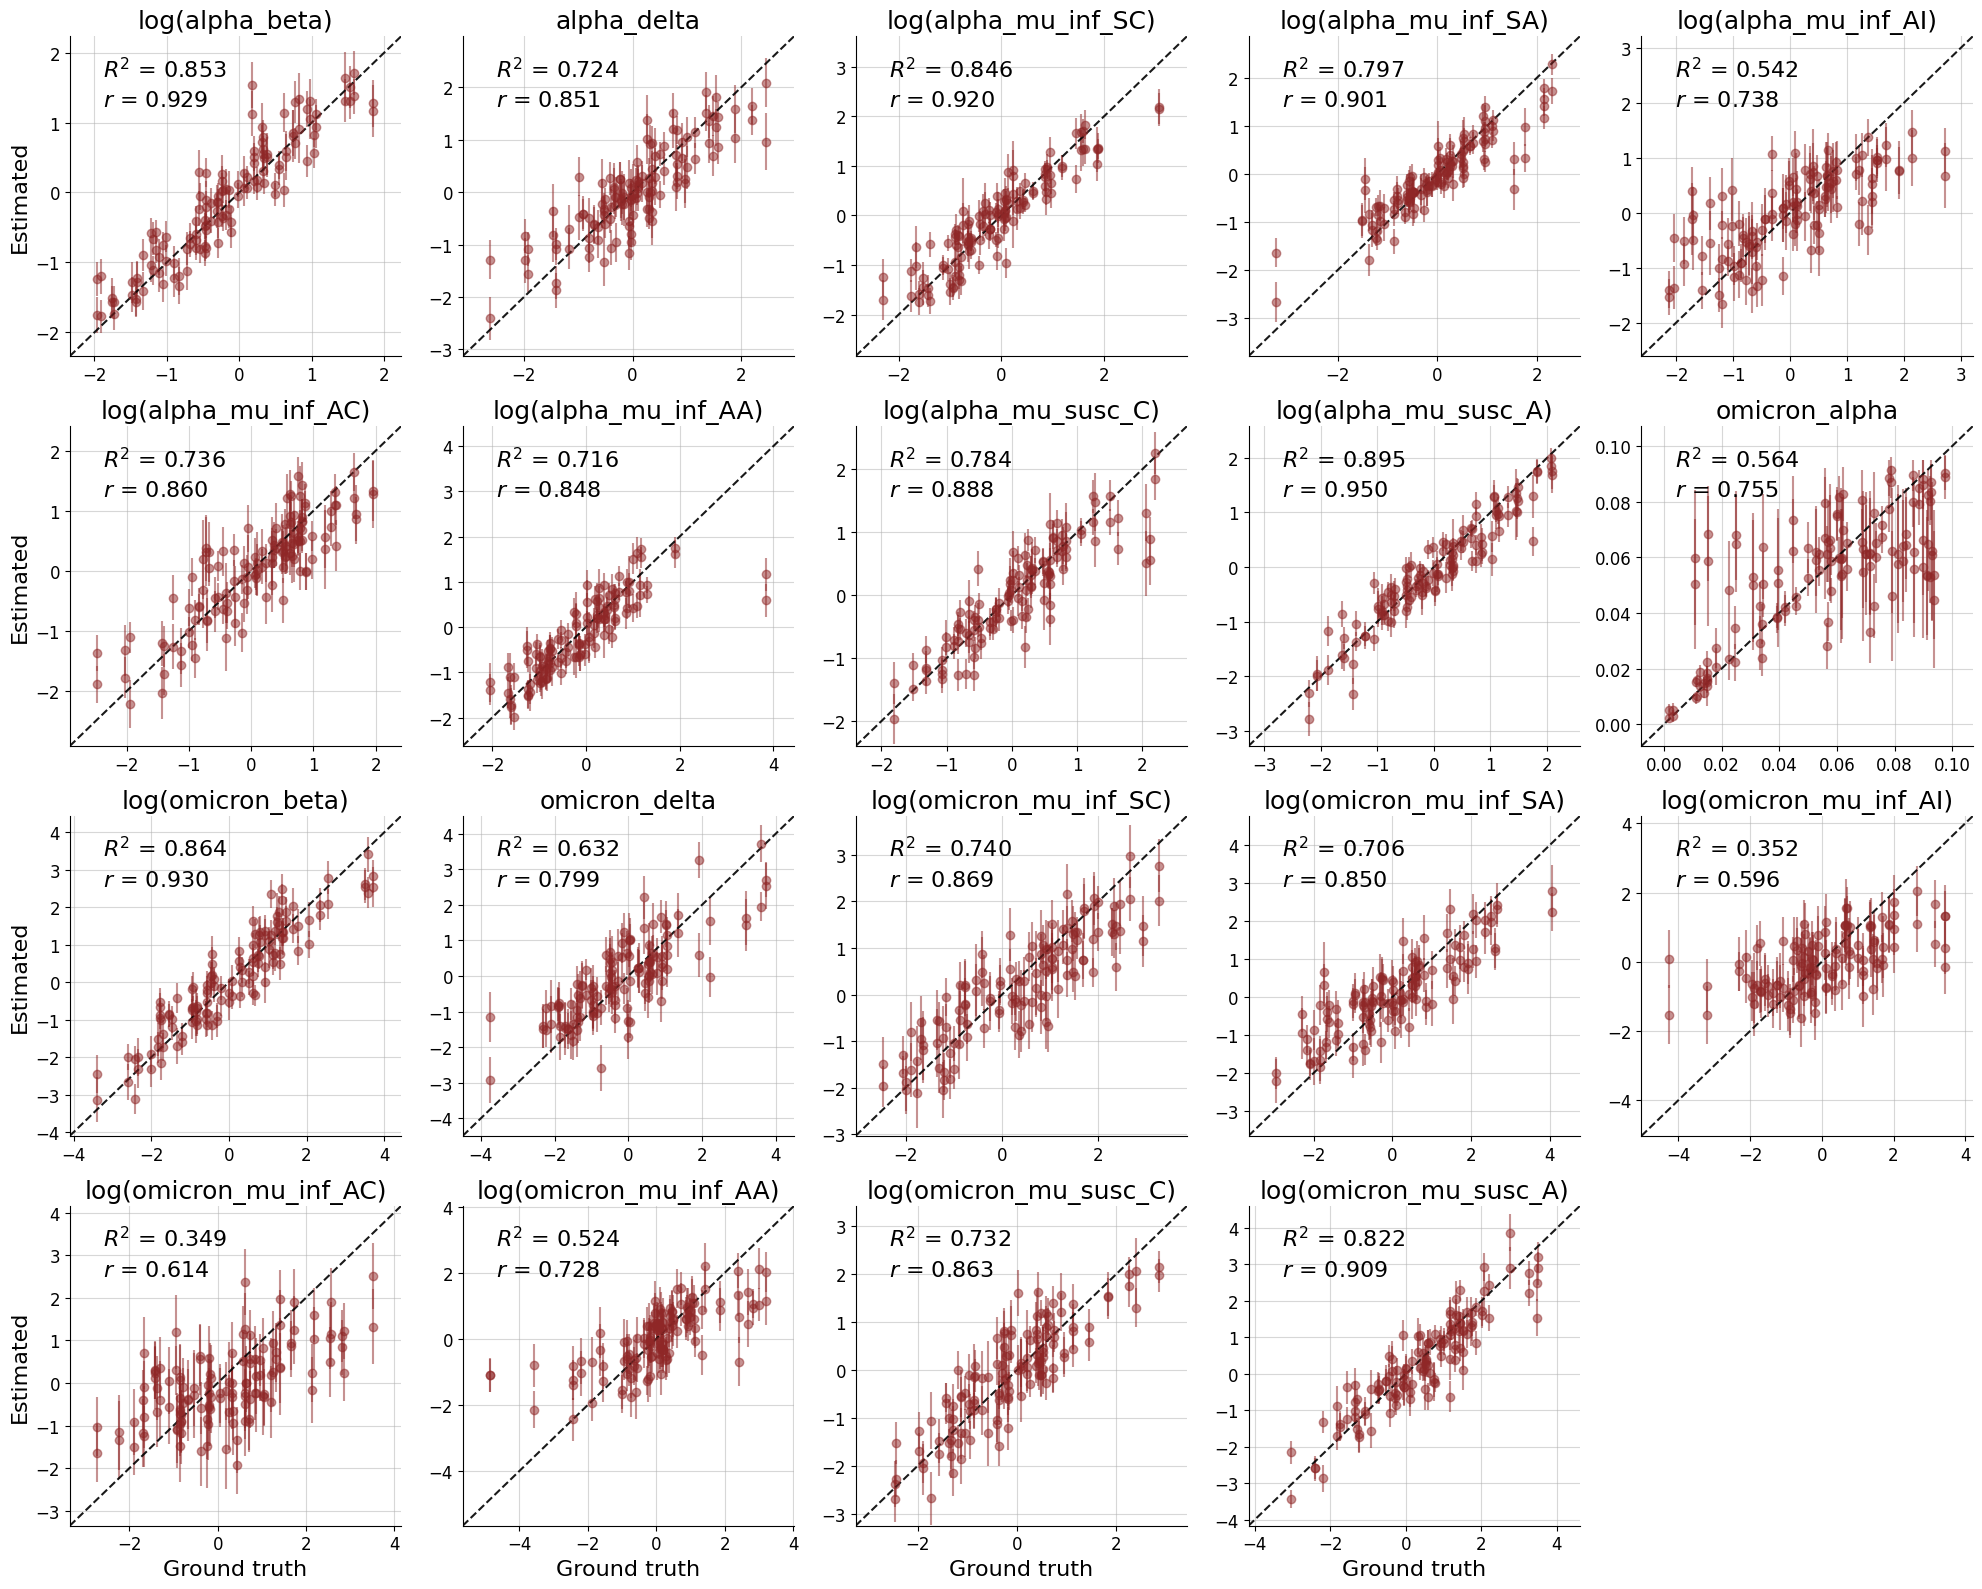

In [28]:
bf.diagnostics.plot_recovery(posterior_samples[~remove], prior_draws[~remove], param_names=log_param_names);

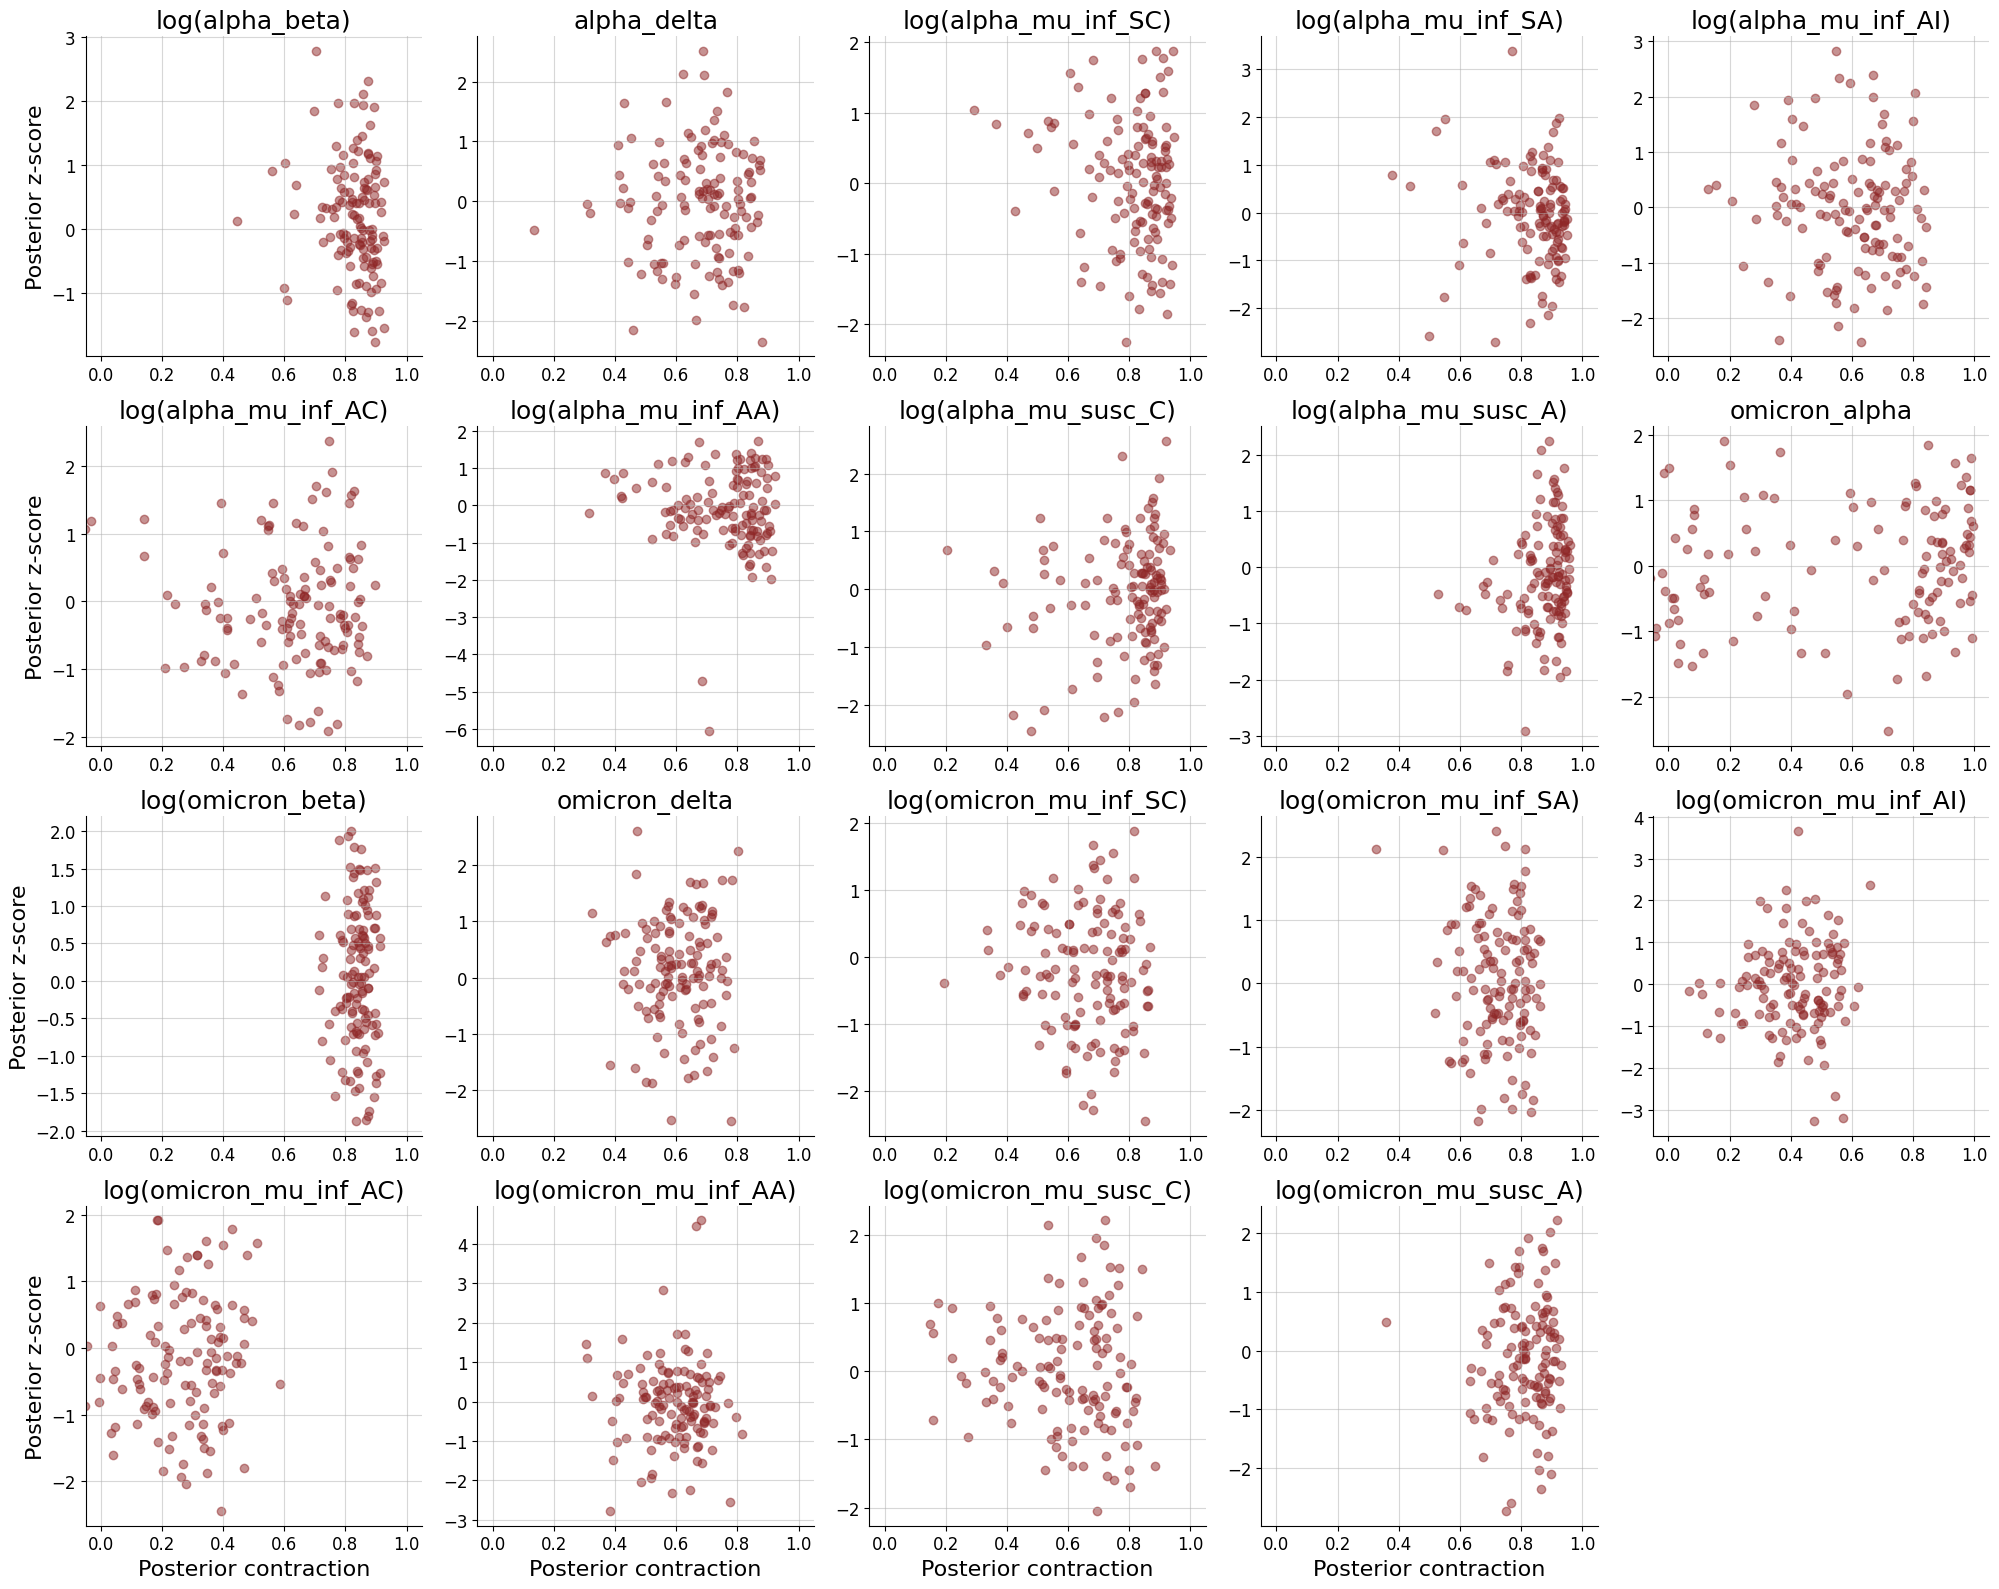

In [29]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=log_param_names);

In [30]:
posterior_samples_reshaped = posterior_samples.reshape(posterior_samples.shape[1], posterior_samples.shape[0], posterior_samples.shape[2])
ecp_bootstrap, alpha = get_tarp_coverage(posterior_samples_reshaped, prior_draws, references='random', 
                                         metric='euclidean', norm=True, bootstrap=True)

100%|██████████| 100/100 [00:00<00:00, 977.69it/s]


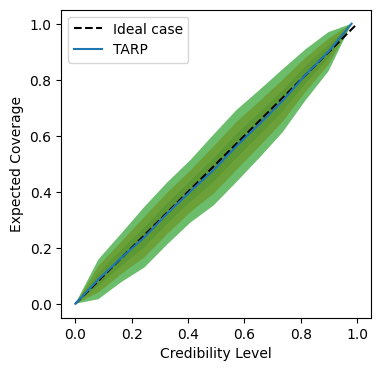

In [31]:
k_sigma = [1, 2, 3]

_, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label="Ideal case")
ax.plot(alpha, ecp_bootstrap.mean(axis=0), label='TARP')
for k in k_sigma:
    ax.fill_between(alpha, 
                    ecp_bootstrap.mean(axis=0) - k * ecp_bootstrap.std(axis=0), 
                    ecp_bootstrap.mean(axis=0) + k * ecp_bootstrap.std(axis=0), 
                    alpha = 0.7)
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")
plt.show()

# Test inference on synthetic data for both recruitment scenarios and variants

Testing scenario pedcov


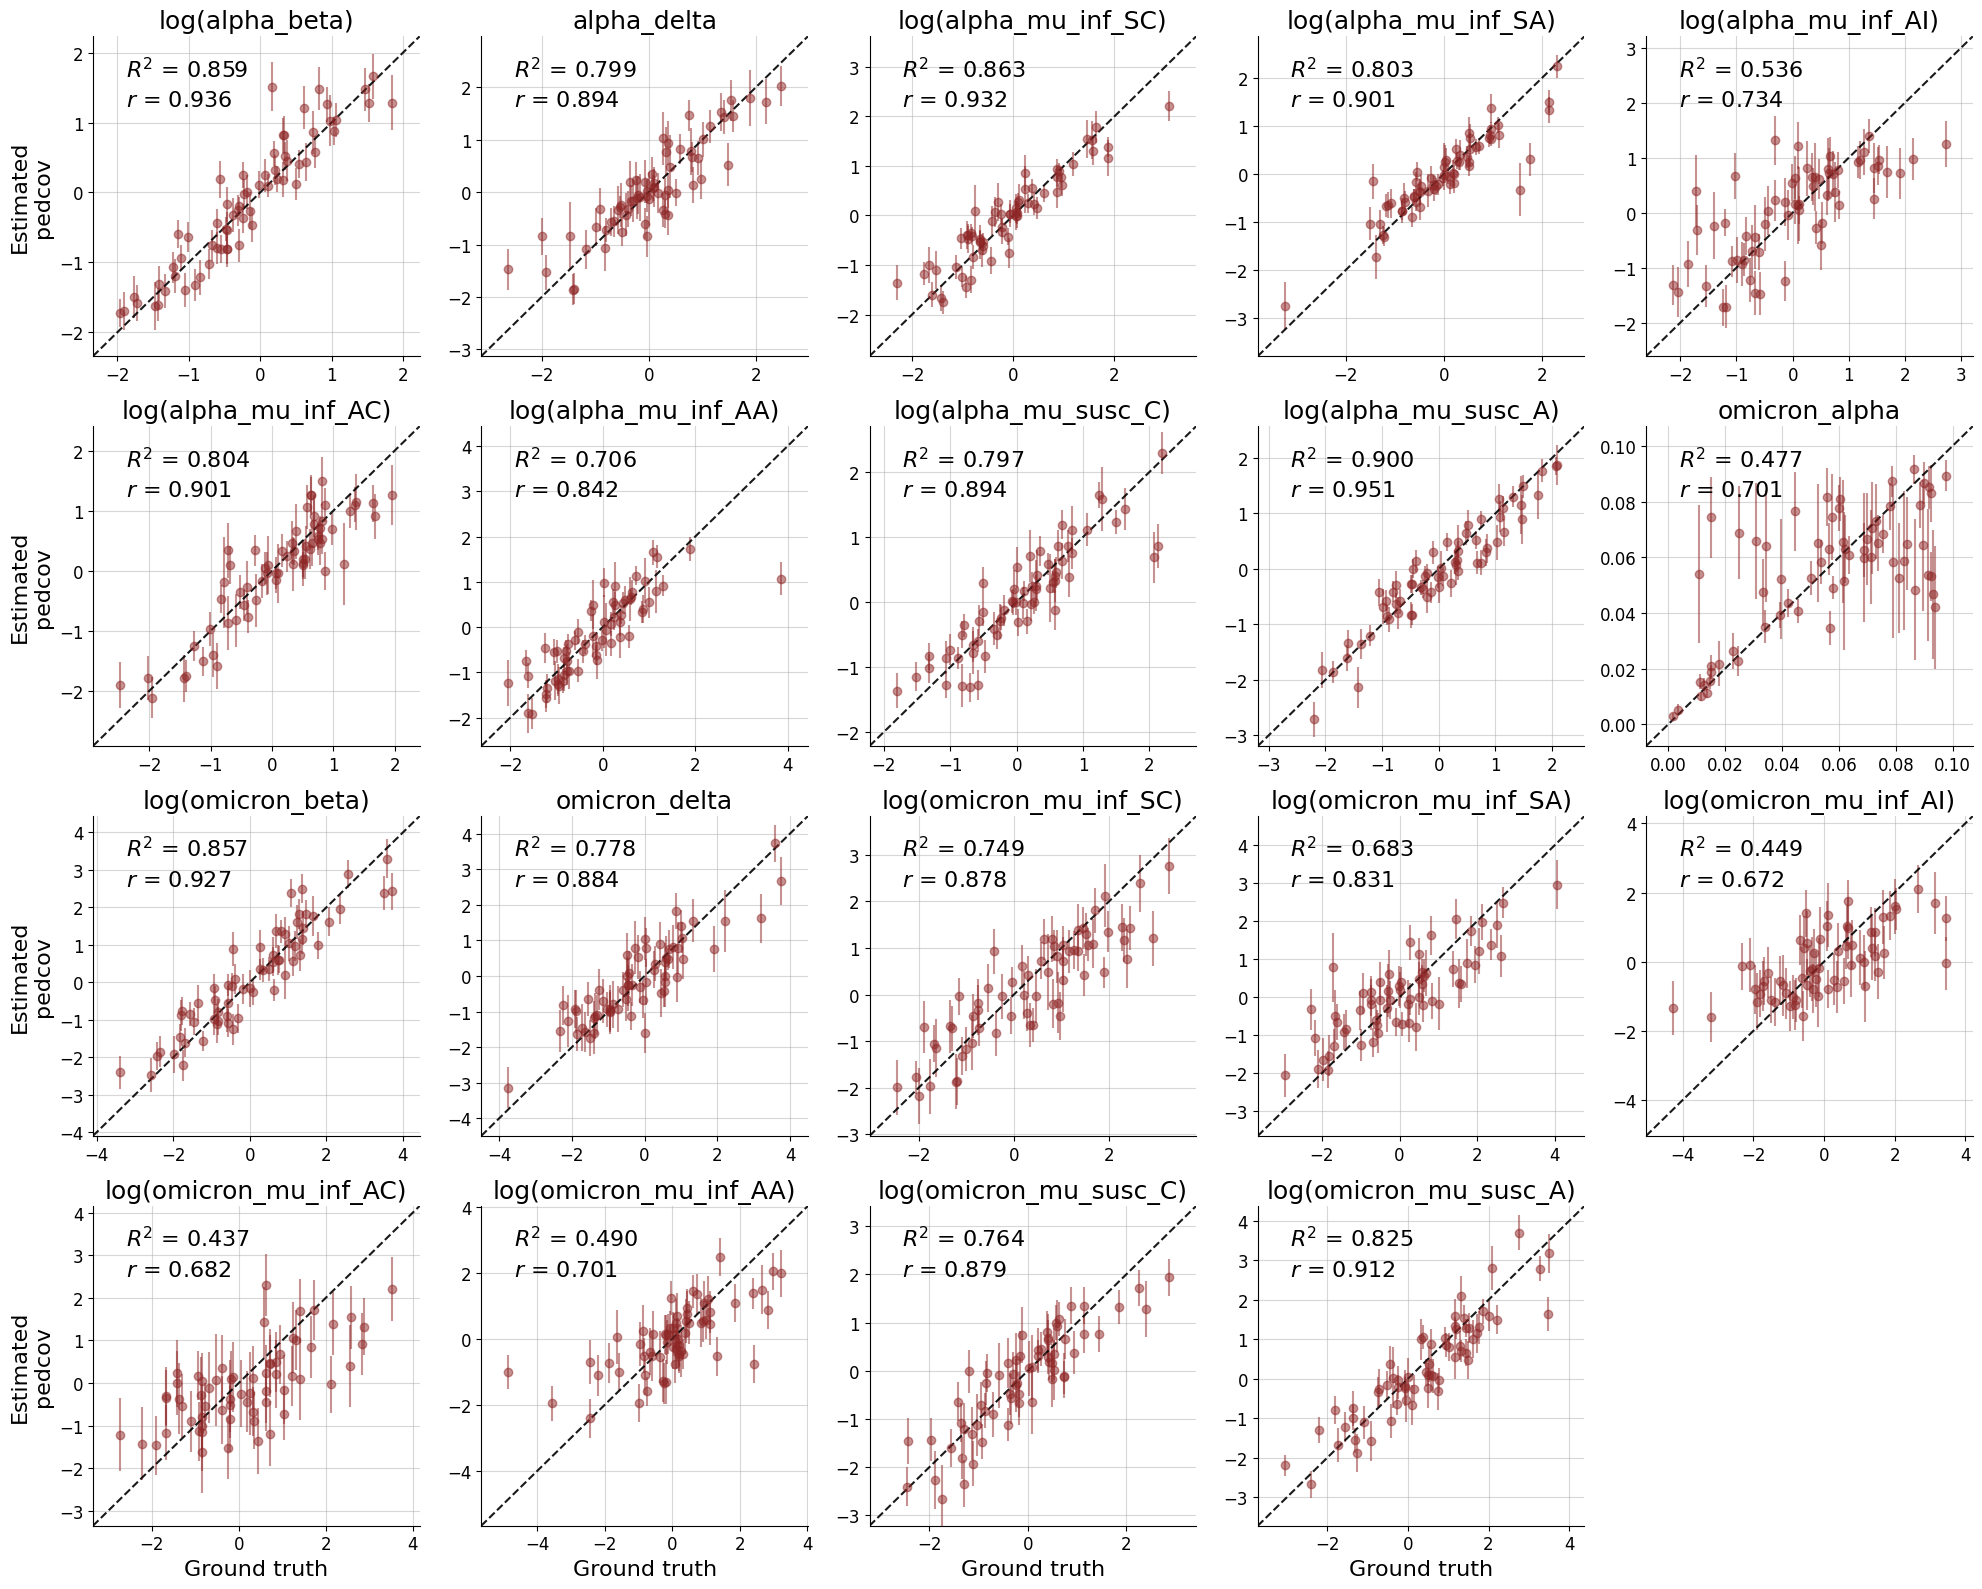

Testing scenario random


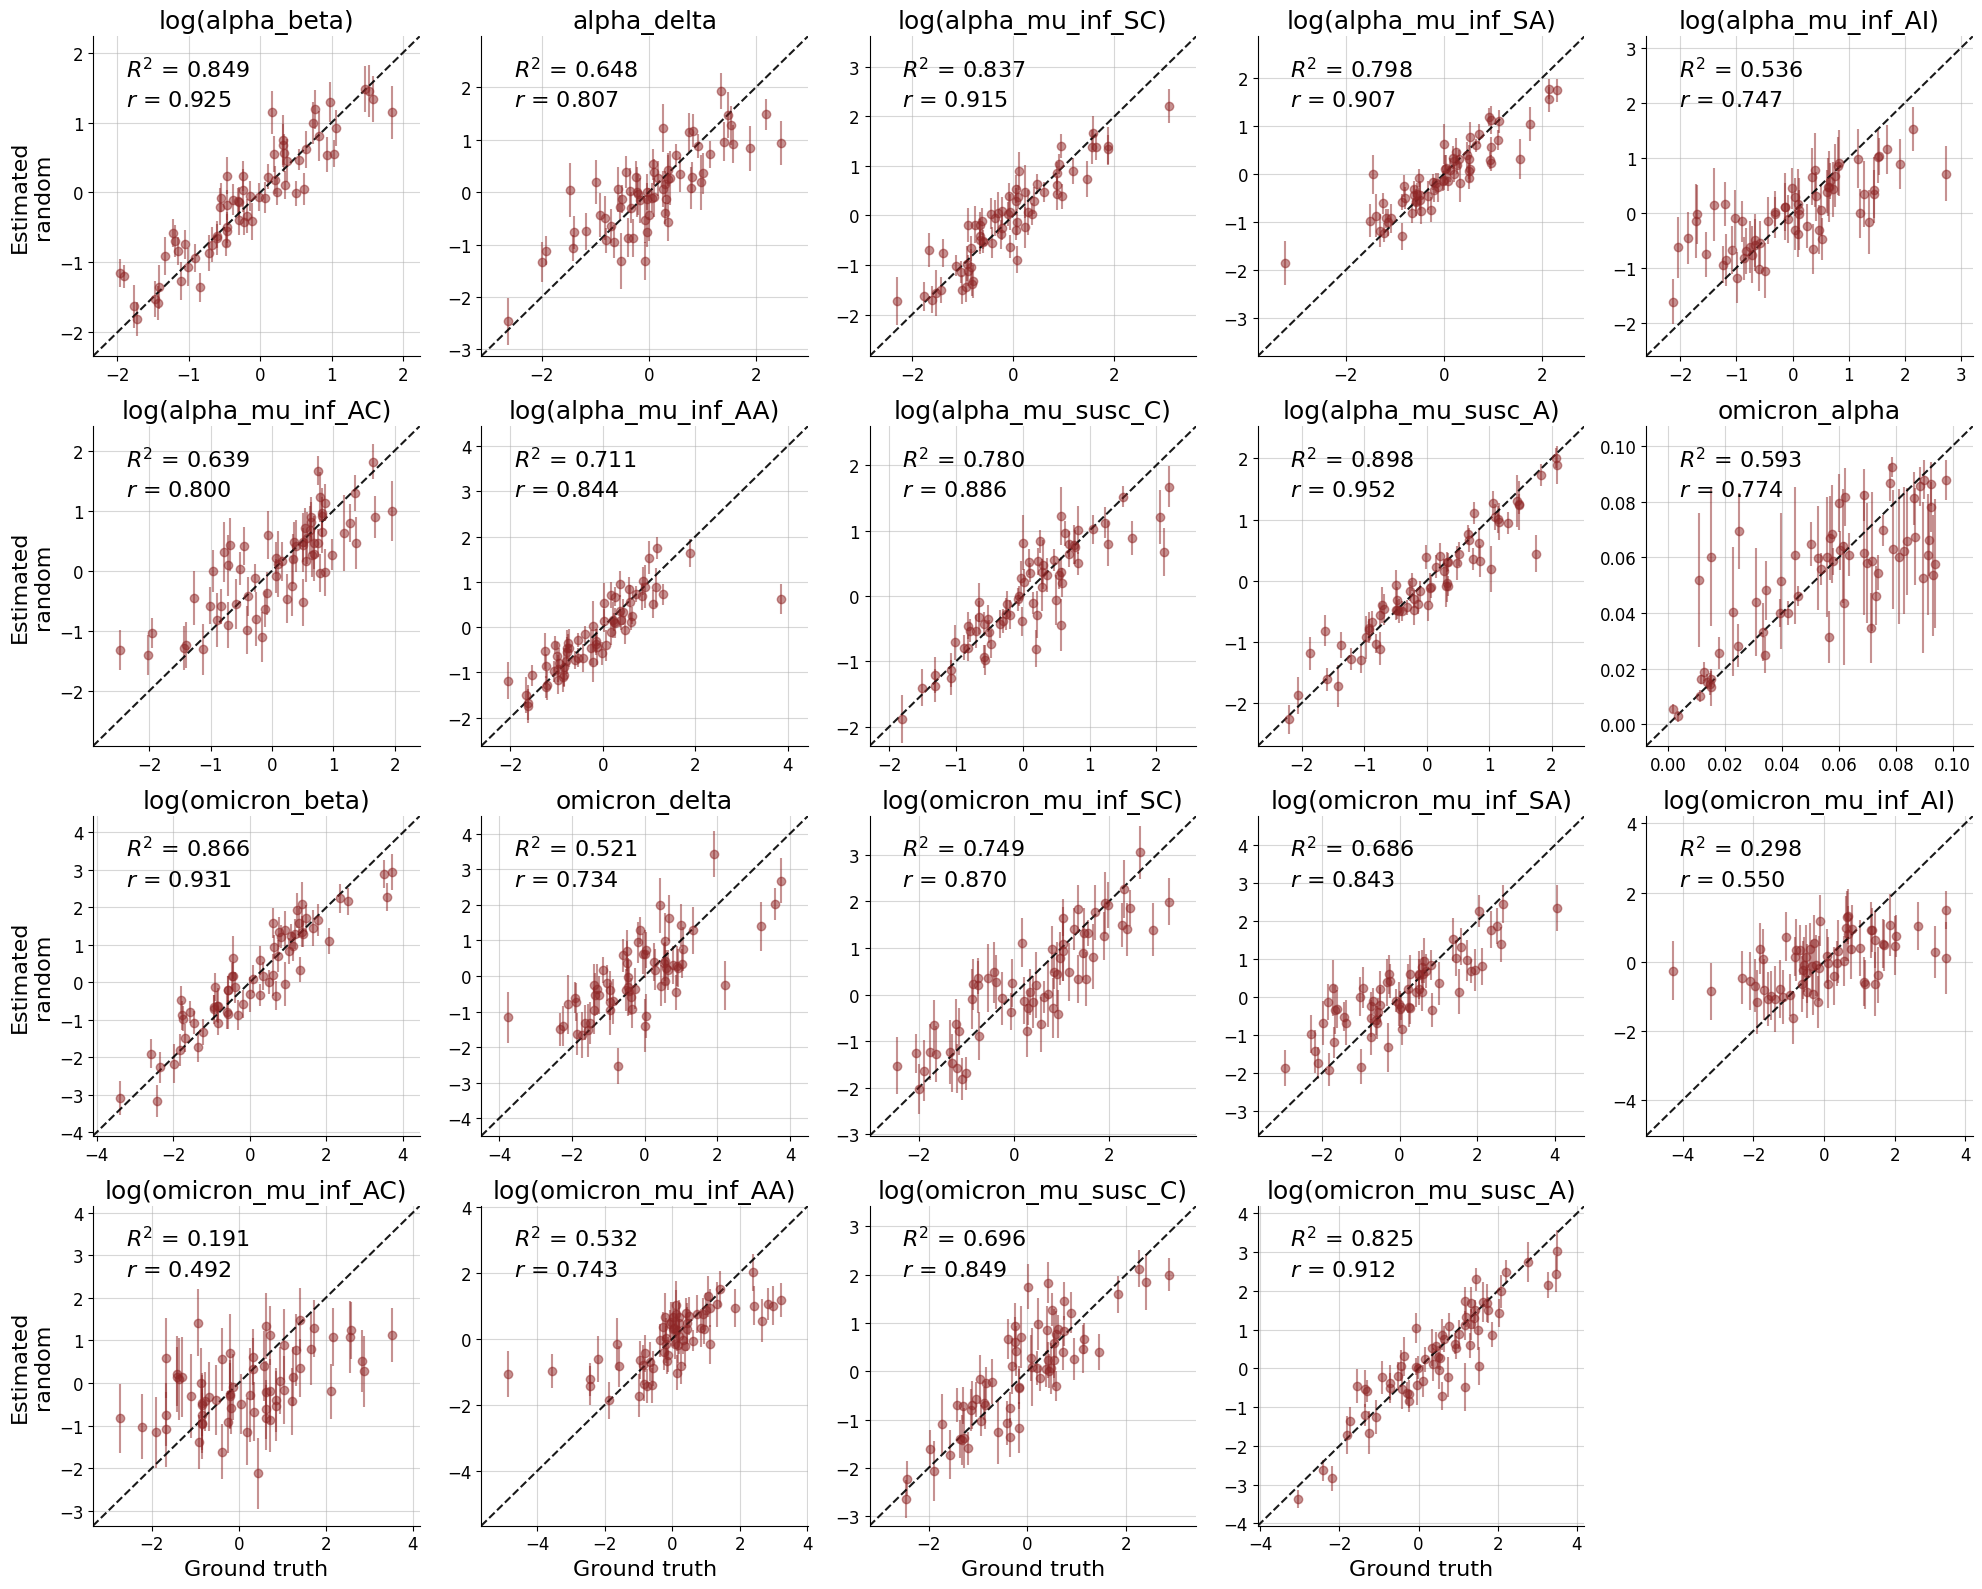

In [32]:
n_samples = 100

test_scenarios_posterior_samples = {}
for test_scenario in valid_data_dict.keys():
    print(f"Testing scenario {test_scenario}")
    test_sims = trainer.configurator(valid_data_dict[test_scenario])
    posterior_samples = amortizer.sample(test_sims, n_samples=n_samples)
    posterior_samples = renormalize_params(posterior_samples, keep_transform=True)
    test_scenarios_posterior_samples[test_scenario] = posterior_samples
    prior_draws = renormalize_params(test_sims["parameters"], keep_transform=True)
    fig = bf.diagnostics.plot_recovery(posterior_samples, prior_draws,
                                       ylabel=f'Estimated\n{test_scenario}',
                                       param_names=log_param_names)
    fig.savefig(f'{results_folder}/{amortizer_name}_recovery_{test_scenario}.png')
    plt.show()

### Check summary statistics in latent space

One should not be able to distinguish between the two variants or the scenarios in the latent space.
This is a good sign that the amortizer is working correctly.
Later we can test if the real data is also indistinguishable in the latent space.


  0%|          | 0/1000 [00:00<?, ?it/s]

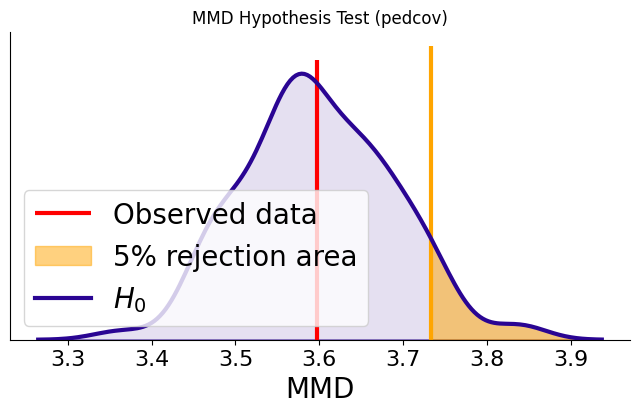

  0%|          | 0/1000 [00:00<?, ?it/s]

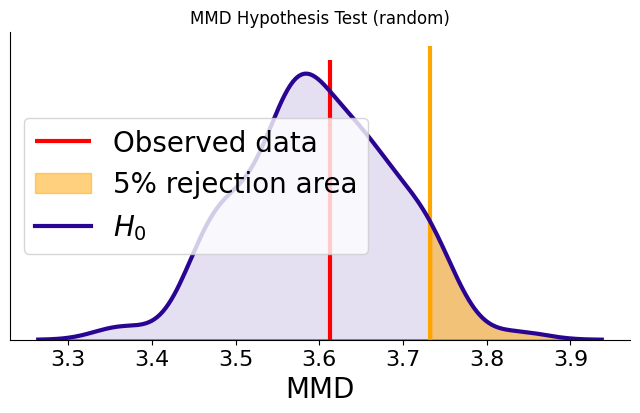

In [33]:
if summary_loss is not None:
    np.random.seed(0)
    sim_id = np.random.randint(0, n_valid // 4)
    for selection in ['pedcov', 'random']:
        test_sims = trainer.configurator(valid_data_dict['pedcov'])
        test_sims_rand = trainer.configurator(valid_data_dict[f'{selection}'])

        MMD_sampling_distribution, MMD_observed = trainer.mmd_hypothesis_test(
            observed_data=test_sims_rand["summary_conditions"][sim_id][np.newaxis],
            reference_data=test_sims,  # if not provided, will use the generative model
            num_null_samples=1000,
            bootstrap=True  # if True, use the reference data as null samples
        )
        fig = bf.diagnostics.plot_mmd_hypothesis_test(MMD_sampling_distribution, MMD_observed)
        plt.title(f"MMD Hypothesis Test ({selection})")
        #fig.savefig(f'{results_folder}/{amortizer_name} MMD.png', bbox_inches='tight')
        plt.show()

## Bias Estimation

bias found in simulation study (when using PedCov as selection procedure) with MCMC:
- overestimation of mu_inf_SA, mu_inf_AA (infectiousness of adults)
- underestimation of mu_susc_A (susceptibility of adults)

Here we should not see any bias anymore, since we condition on the recruitment procedure and variant.

### Simulation Study

All parameters are set to 1 besides one parameter. Inference workflow applied on the full model still. Check if for the changing parameter the true parameter is still recovered.

Here we tell the network the right selection procedure. Results should be not be biased for no selection procedure. 

In [34]:
# generate simulation study or load data
simulation_study_file_name = "sim_study_data_both_variants"
n_sims_per_param = 50

np.random.seed(42)
prior_draws_sim_study = bayesflow_prior(n_sims_per_param)['prior_draws']
non_fix_indices_study = np.arange(n_params)
fix_indices_study = np.array([param_names.index('alpha_beta'),
                       param_names.index('alpha_delta'),
                       param_names.index('omicron_alpha'),
                       param_names.index('omicron_beta'),
                       param_names.index('omicron_delta')])
non_fix_indices_study = np.delete(non_fix_indices_study, fix_indices_study)
prior_draws_sim_study[:, fix_indices_study] = np.array([np.log(0.2), 1.3, 0.002, np.log(0.2), 1.3])

sim_study_dict = {}
sim_study_bias_dict = {}

for selection in ['pedcov', 'random']:
    
    study_file_name_vs = f"{simulation_study_file_name}_{selection}"
    if os.path.exists(f'{sim_folder}/{study_file_name_vs}.pickle'):
        with open(f'{sim_folder}/{study_file_name_vs}.pickle', 'rb') as f:
            sim_study_dict[f'{selection}'] = pickle.load(f)
    else:
        print(f"Simulating simulation study with {selection}")
        new_sim_data = {
            'prior_draws': np.zeros((len(non_fix_indices_study), n_sims_per_param, n_params)),  # all parameters are set to log(1)
            'sim_batchable_context': np.array([[[selection] for _ in range(n_sims_per_param)]
                                               for _ in range(len(non_fix_indices_study))]),
            'sim_data': np.empty((len(non_fix_indices_study), n_sims_per_param,
                                  valid_data_dict[f'{selection}']['sim_data'].shape[1],
                                  valid_data_dict[f'{selection}']['sim_data'].shape[2], 
                              valid_data_dict[f'{selection}']['sim_data'].shape[3])),
        }
        for i, index_i in enumerate(non_fix_indices_study):
            # set all except the i-th parameter to log(1)
            new_sim_data['prior_draws'][i, :, index_i] = prior_draws_sim_study.copy()[:, index_i]
            new_sim_data['prior_draws'][i, :, fix_indices_study] = prior_draws_sim_study.copy()[:, fix_indices_study].T  # fix params
            new_sim_data['sim_data'][i] = np.array([simulator_both_variants(params,
                                                                           selection_procedure=selection,
                                                                           fixed_parameters_dict=fixed_parameters) 
                                                      for params in new_sim_data['prior_draws'][i]])
        # save the data
        with open(f'{sim_folder}/{study_file_name_vs}.pickle', 'wb') as f:
            pickle.dump(new_sim_data, f)
        sim_study_dict[f'{selection}'] = new_sim_data

In [35]:
# perform inference on simulation study
results_sim_study = {} 
n_samples_study = 10 # increase for more accurate results, e.g. 1000 samples

for selection_data, selection_inference in tqdm(product(['pedcov', 'random'], ['pedcov', 'random']), total=4):
    # estimate median and CI for each parameter
    results_sim_study_vs = {
        'posterior_median': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
        'posterior_CI': np.ones((len(non_fix_indices_study), 6, n_sims_per_param)) * np.nan,
        'relative_bias_median': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
        'relative_bias_CI': np.ones((len(non_fix_indices_study), 6, n_sims_per_param)) * np.nan,
        'overall_median_error': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
    }
    for i, index_i in enumerate(non_fix_indices_study):
        # get data for this parameter
        sim_study_i = {
            'sim_data': sim_study_dict[f'{selection_data}']['sim_data'][i],
            'prior_draws': sim_study_dict[f'{selection_data}']['prior_draws'][i],
            # on purpose a different selection procedure than the data was generated with
            'sim_batchable_context': sim_study_dict[f'{selection_inference}']['sim_batchable_context'][i],
        }
        simulation_study_data_conf = trainer.configurator(sim_study_i)
        # get posterior samples
        posterior_samples_sim_study = (
            amortizer.sample(simulation_study_data_conf, n_samples=n_samples_study)
        )
        posterior_samples_sim_study = renormalize_params(posterior_samples_sim_study, keep_transform=False)
        prior_draws_study = renormalize_params(simulation_study_data_conf['parameters'], keep_transform=False)

        # get median and CI for each parameter of posterior samples
        # we only care about the changing parameter, the others are set to 1
        results_sim_study_vs['posterior_median'][i] = np.median(posterior_samples_sim_study[:, :, index_i], axis=1)
        results_sim_study_vs['posterior_CI'][i] = np.quantile(posterior_samples_sim_study[:, :, index_i],
                                                                           [0.005, 0.025, 0.1,
                                                                            0.995, 0.975, 0.9],
                                                                           axis=1)
        # get median and CI for each parameter of relative bias (estimate - true) / true
        relative_bias = (posterior_samples_sim_study[:, :, index_i] - prior_draws_study[:, index_i][:, np.newaxis]) / prior_draws_study[:, index_i][:, np.newaxis]
        results_sim_study_vs['relative_bias_median'][i] = np.median(relative_bias, axis=1)
        results_sim_study_vs['relative_bias_CI'][i] = np.quantile(relative_bias,
                                                                               [0.005, 0.025, 0.1,
                                                                                0.995, 0.975, 0.9],
                                                                               axis=1)
        # order the relative bias by size of the true parameters
        ordering = np.argsort(sim_study_i['prior_draws'][:, index_i])
        results_sim_study_vs['relative_bias_median'][i] = results_sim_study_vs['relative_bias_median'][i][ordering]
        results_sim_study_vs['relative_bias_CI'][i] = results_sim_study_vs['relative_bias_CI'][i][:, ordering]

        # get overall median error
        results_sim_study_vs['overall_median_error'][i] = np.sum(
            (np.median(posterior_samples_sim_study, axis=1) - prior_draws_study)**2, axis=1
        )

    results_sim_study[f'{selection_data}_{selection_inference}'] = results_sim_study_vs

100%|██████████| 4/4 [02:01<00:00, 30.31s/it]


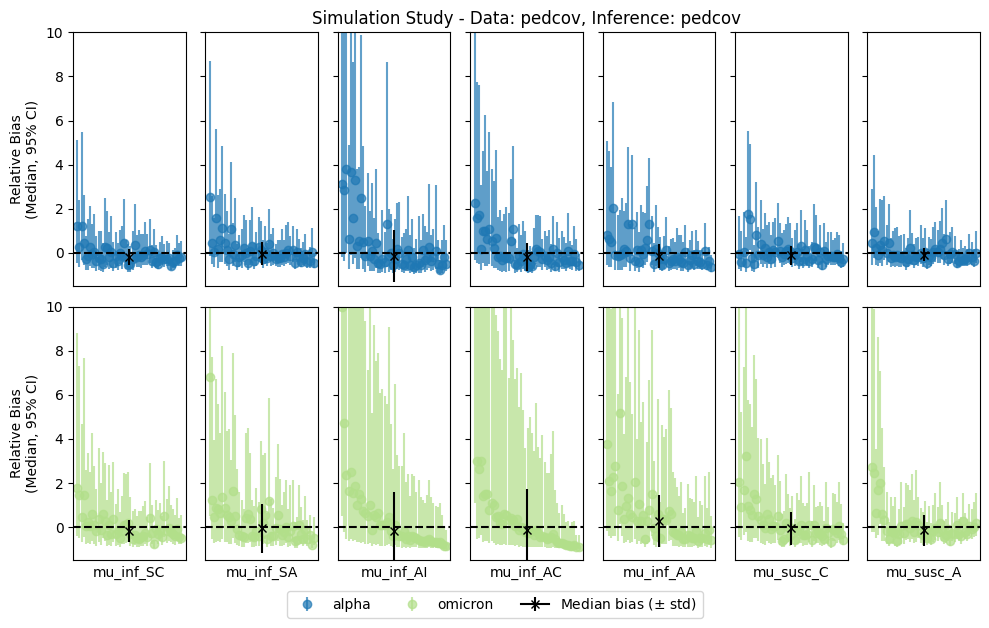

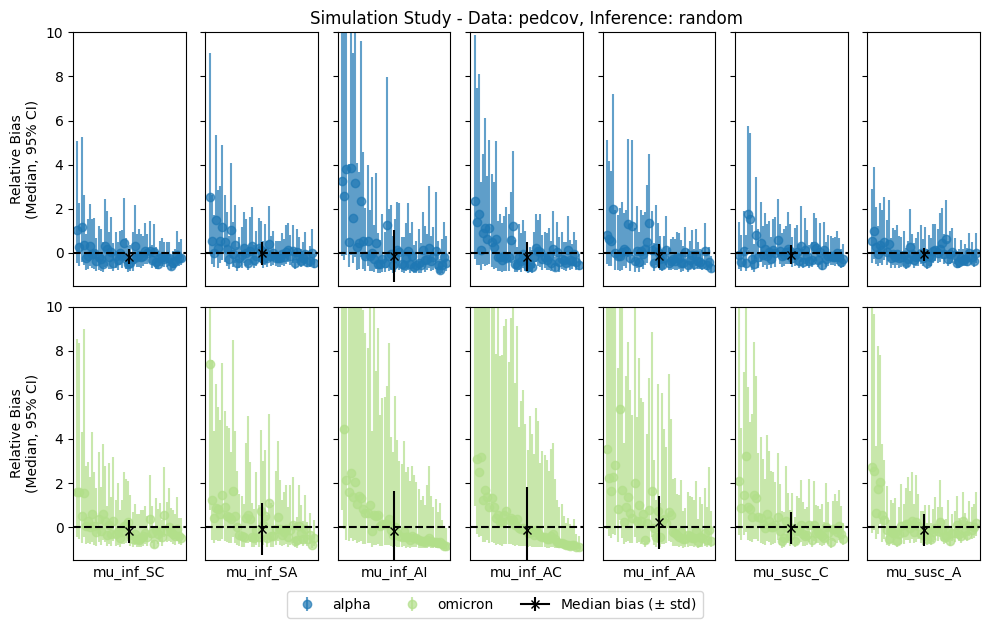

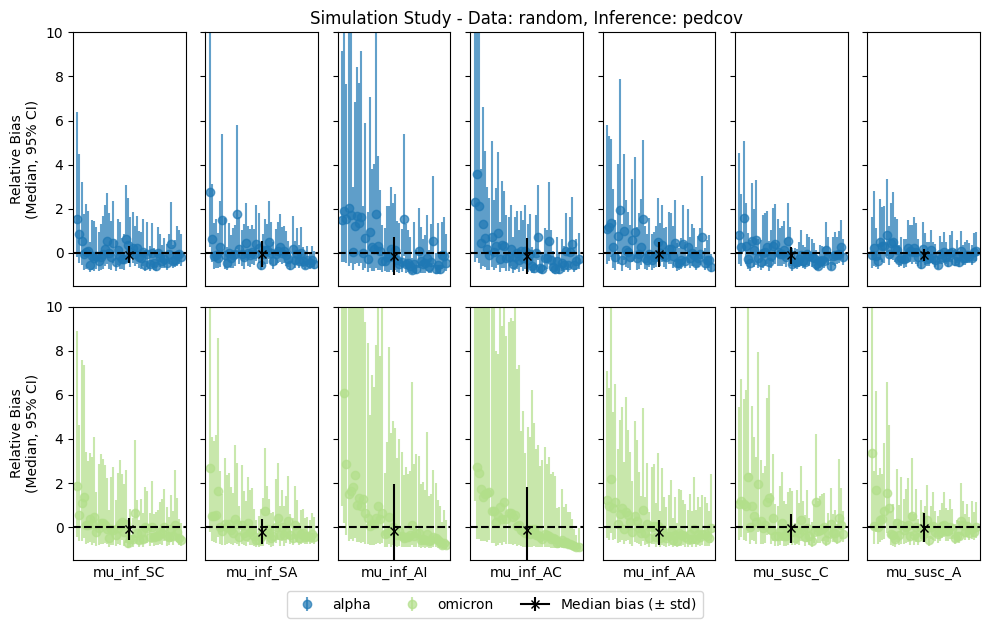

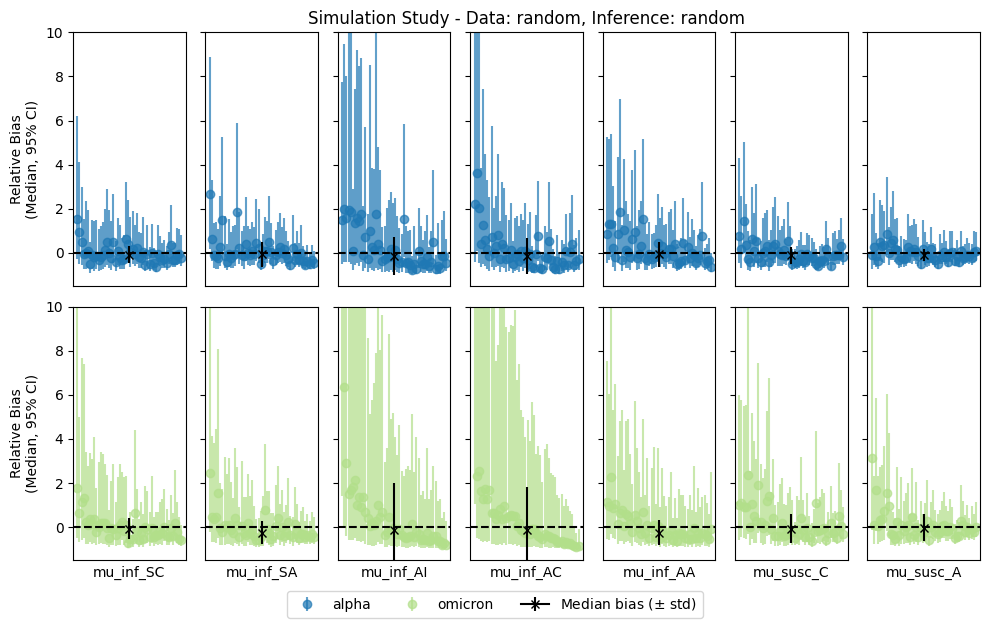

In [36]:
# plot the results
for selection_data, selection_inference in product(['pedcov', 'random'], ['pedcov', 'random']):
    fig, ax = plt.subplots(2, 7, sharex=True, sharey=True, figsize=(10, 6), tight_layout=True)
    space = 1. / n_sims_per_param
    ci_level = 0.95
    ci_interval = {0.99: [0, 3], 0.95: [1, 4], 0.8: [2, 5]}[0.95]
    colors = ['#1f78b4', '#b2df8a']
    
    handles = ['', '']
    handles_mean = ['', '']
    for j, variant in enumerate(['alpha', 'omicron']):
        i_plot = 0
        for i_total, index_i in enumerate(non_fix_indices_study):
            if variant == 'alpha':
                if param_names[index_i] not in param_names_a:
                    continue
            else:
                if param_names[index_i] not in param_names_o:
                    continue

            relative = results_sim_study[f'{selection_data}_{selection_inference}']['relative_bias_median'][i_total]

            handles[j] = ax[j, i_plot].errorbar(np.arange(n_sims_per_param)*space,
                                                relative,
                                                yerr=np.abs(results_sim_study[f'{selection_data}_{selection_inference}']['relative_bias_CI'][i_total][ci_interval] - results_sim_study[f'{selection_data}_{selection_inference}']['relative_bias_median'][i_total]),
                                                fmt='o', color=colors[j], alpha=0.7, label=f'{variant}')
            handles_mean[j] = ax[j, i_plot].errorbar((n_sims_per_param-1)*space*0.5,
                                                     np.median(relative),
                                                     yerr=np.std(relative),
                                                     color='black', marker='x', label=r'Median bias ($\pm$ std)', zorder=4)

            ax[j, i_plot].axhline(0, color='black', ls='--', zorder=3)
            ax[0, i_plot].set_xlim(-space-space, n_sims_per_param*space+space)
            ax[0, i_plot].set_xticks([])
            if j == 0:
                ax[1, i_plot].set_xlabel(param_names_raw[index_i+1])  # raw has still alpha in it
            i_plot += 1
    ax[0, 0].set_ylabel(f'Relative Bias\n(Median, {round(ci_level*100)}% CI)')
    ax[1, 0].set_ylabel(f'Relative Bias\n(Median, {round(ci_level*100)}% CI)')
    ax[0, 7//2].set_title(f'Simulation Study - Data: {selection_data}, Inference: {selection_inference}')
    ax[0, 0].set_ylim(-1.5, 10)
    fig.legend(handles=handles+[handles_mean[0]],
                loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig.savefig(f'{results_folder}/{amortizer_name}_sim_study_data_'
                f'{selection_data}_vs_inference_{selection_inference}.png', bbox_inches='tight')
    plt.show()

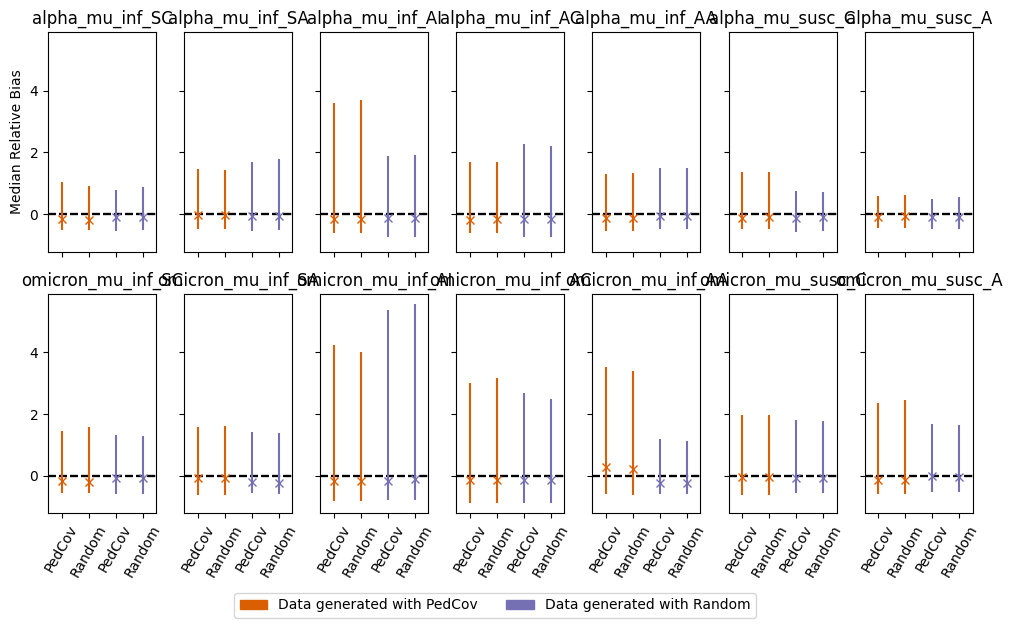

In [37]:
# plot bias in both scenarios
fig, ax = plt.subplots(2, len(non_fix_indices_study) // 2, sharex=True, sharey=True, figsize=(10, 6), tight_layout=True)
colors = ['#d95f02', '#7570b3']
ax = ax.flatten()

for j, (selection_data, selection_inference) in enumerate(product(['pedcov', 'random'], ['pedcov', 'random'])):
    for i, index_i in enumerate(non_fix_indices_study):
        # plot a line around 0
        ax[i].axhline(0, color='black', ls='--', zorder=3)

        relative = results_sim_study[f'{selection_data}_{selection_inference}']['relative_bias_median'][i]

        # Define the error as [lower_error, upper_error]
        lower_quantile, upper_quantile = np.quantile(relative, [0.025, 0.975])
        yerr_alpha = np.array([[np.median(relative) - lower_quantile],
                               [upper_quantile - np.median(relative)]])
        handle_mean = ax[i].errorbar(j,
                                     np.median(relative),
                                     yerr=yerr_alpha,
                                     color=colors[j // 2], marker='x', label=r'Median Bias', zorder=4)
        ax[i].set_title(param_names[index_i])
        ax[i].set_xlim(-0.5, 3.5)
        ax[i].set_xticks([0, 1, 2, 3], labels=['PedCov', 'Random', 'PedCov', 'Random'], rotation=60)
        ax[0].set_ylabel('Median Relative Bias')

color_patch = [Patch(color=colors[i], label=f'Data generated with {["PedCov", "Random"][i]}') for i in range(2)]
leg = fig.legend(handles=color_patch, bbox_to_anchor=(0.5, -0.05), loc='lower center', ncol=2)
fig.savefig(f'{results_folder}/{amortizer_name}_sim_study_data_bias.png', bbox_inches='tight')
plt.show()

# Apply inference on real data

In [38]:
# specify the data path
data_path_alpha = 'data/simulated_data_formatted_alpha_rnd_1.txt'  # todo: exchange with real data of alpha
data_path_omicron = 'data/simulated_data_formatted_alpha_rnd_1.txt'  # todo: exchange with real data of omicron
os.makedirs(results_folder+'/real data', exist_ok=True)

In [39]:
# load the data
dfs = {
    'alpha': pd.read_csv(data_path_alpha, delimiter=' ', index_col=0),
    'omicron': pd.read_csv(data_path_omicron, delimiter=' ', index_col=0)
}
prior_samples = renormalize_params(prior(1000))

# prepare the data for neural networks and concatenate both variants
household_data = []
for variant in ['alpha', 'omicron']:
    household_data_v = normalize_household_data(dfs[variant], minimal_length=9)
     # add variant as feature
    if variant == 'alpha':
        variant_feature = np.zeros((household_data_v.shape[0], 9, 1))
    else:
        variant_feature = np.ones((household_data_v.shape[0], 9, 1))
    household_data_v = np.concatenate((household_data_v, variant_feature), axis=-1)
    household_data.append(household_data_v)   
household_data = np.concatenate(household_data, axis=0)[np.newaxis]

real_data_dict = {
    'sim_data': household_data,
    'sim_batchable_context': 'pedcov'
}
real_data = {'data': trainer.configurator(real_data_dict)}

In [40]:
# get posterior samples
posterior_samples_real = (
    amortizer.sample(real_data['data'], n_samples=prior_samples.shape[0])
)
real_data['posterior_samples'] = renormalize_params(posterior_samples_real)

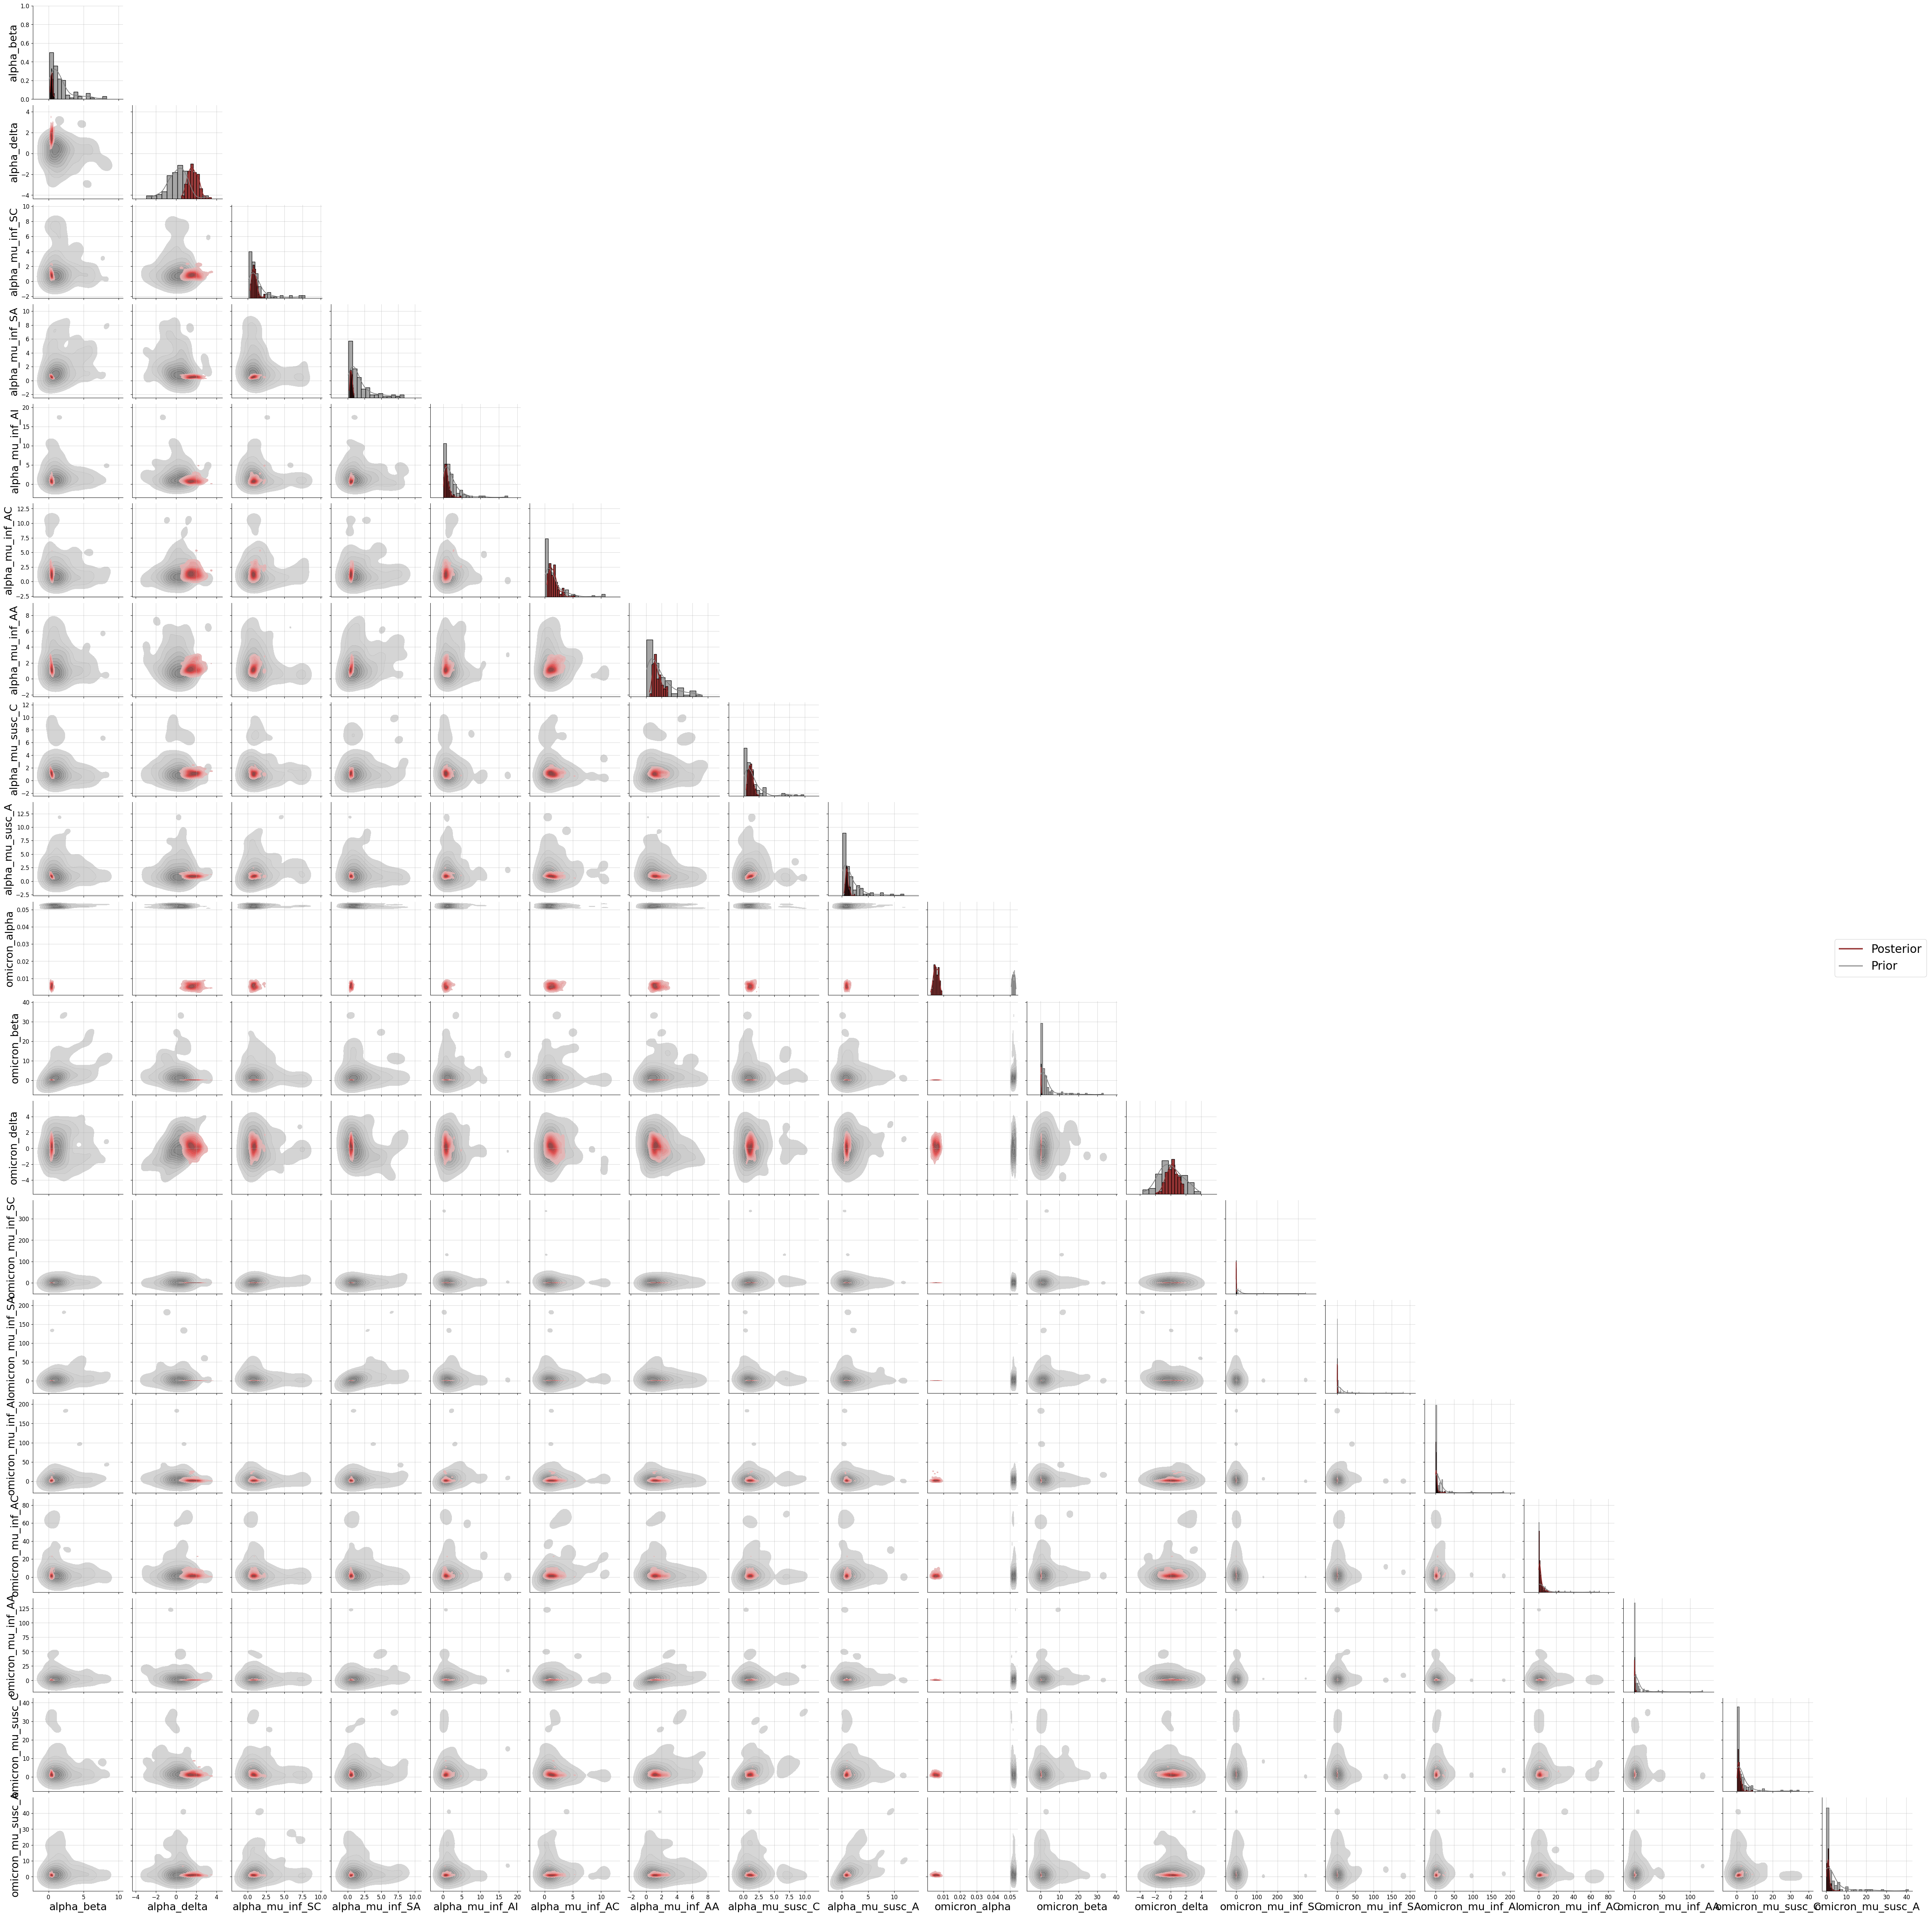

In [41]:
# plot posterior samples vs prior
fig = bf.diagnostics.plot_posterior_2d(
    posterior_draws=real_data['posterior_samples'][:100],
    prior_draws=prior_samples[:100],
    param_names=param_names,
    label_fontsize=22,
    legend_fontsize=24
)
plt.savefig(f'{results_folder}/real data/posterior_{variant}.png', bbox_inches='tight')
plt.show()

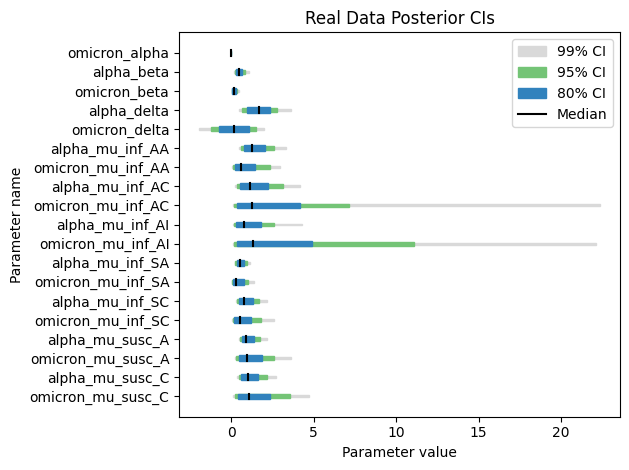

In [42]:
# Sort based on the part after the first underscore
sorted_indices = [param_names.index(variant) for variant in sorted(param_names, key=lambda x: x.split('_', 1)[1])]

# plot credible intervals for each parameter and each variant
sampling_parameter_cis(real_data['posterior_samples'][:, sorted_indices], alpha=[99, 95, 80],
                       param_names=np.array(param_names)[sorted_indices], 
                       title=f"Real Data Posterior CIs")
plt.savefig(f'{results_folder}/real data/CIs_both.png', bbox_inches='tight')
plt.show()

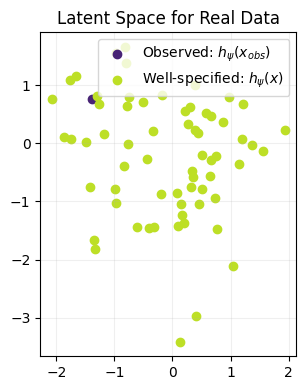

  0%|          | 0/1000 [00:00<?, ?it/s]

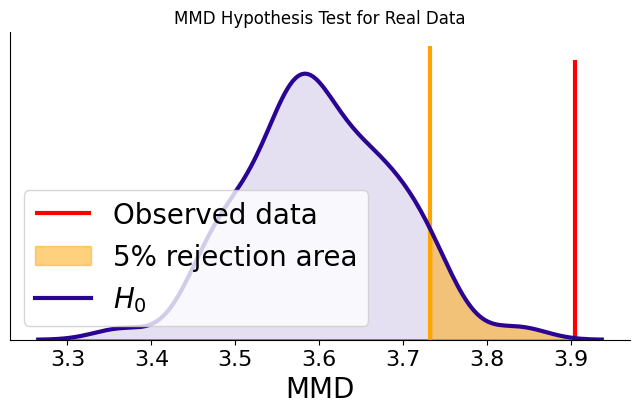

In [43]:
if summary_loss is not None:
    colors = viridis(np.linspace(0.1, 0.9, 2))

    # check latent space as well, distribution can be different but still in-sample
    ref_data = trainer.configurator(valid_data_dict['pedcov'])["summary_conditions"]
    summary_statistics = trainer.amortizer.summary_net(ref_data)
    summary_statistics_obs = trainer.amortizer.summary_net(real_data['data']["summary_conditions"])

    fig, ax = plt.subplots(1, 1, figsize=(4, 4), tight_layout=True)
    ax.scatter(
        summary_statistics_obs[:, 0], summary_statistics_obs[:, 1], color=colors[0], label=r"Observed: $h_{\psi}(x_{obs})$"
    )
    ax.scatter(summary_statistics[:, 0], summary_statistics[:, 1], color=colors[1], label=r"Well-specified: $h_{\psi}(x)$")
    ax.legend(loc='upper right')
    ax.grid(alpha=0.2)
    plt.gca().set_aspect("equal")
    plt.title(f"Latent Space for Real Data")
    plt.savefig(f'{results_folder}/real data/latent_space_{variant}.png', bbox_inches='tight')
    plt.show()

    # check the summary statistics
    MMD_sampling_distribution, MMD_observed = trainer.mmd_hypothesis_test(
        observed_data=real_data['data']["summary_conditions"],
        reference_data=trainer.configurator(valid_data_dict['pedcov']),  # test against pedcov
        bootstrap=True,  # if True, use the reference data as null samples,
        num_null_samples=1000,
    )
    bf.diagnostics.plot_mmd_hypothesis_test(MMD_sampling_distribution, MMD_observed)
    plt.title("MMD Hypothesis Test for Real Data")
    plt.savefig(f'{results_folder}/real data/MMD_{variant}.png', bbox_inches='tight')
    plt.show()